In [1]:
import numpy as np
import pandas as pd
import emcee
import astropy.cosmology as cosmo
import astropy.units as u
from scipy import integrate
from emcee.moves import StretchMove, WalkMove
import pickle
import multiprocessing
import math
import time
from dataclasses import dataclass
from typing import Optional, Tuple, List, Dict, Literal
from pathlib import Path
import warnings
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import arviz as az
from cosmographic_expansions.expansions import ExpansionModels
from cosmographic_expansions.transforms import CosmographicTransforms
from cosmographic_expansions.pade import PadeApproximants 
from cosmographic_expansions.expansions import EISModel, EISModelJAX
from cosmographic_expansions.transforms import EISTransforms
import scienceplots
from astropy.constants import c
import os
import matplotlib.pyplot as plt
plt.style.use(['science', 'notebook', 'grid'])
numpyro.set_platform("gpu")
from astropy.cosmology import FlatLambdaCDM
from matplotlib.colors import TwoSlopeNorm

In [2]:
import numpy as np

def pade_32_denom_GPT(z: np.ndarray, H0: float, q0: float, j0: float = 0,
            s0: float = 0, l0: float = 0, p0: float = 0,
            Ok: float = 0, order: int = 0):

    expr = 3 * (
        -40
        - 60*s0
        - 32*z
        - 12*l0*z
        - 112*s0*z
        - 4*z**2
        + 40*j0**3*z**2
        - 4*l0*z**2
        - 135*q0**6*z**2
        - 24*s0*z**2
        + 5*s0**2*z**2
        - 30*q0**5*z*(12 + 5*z)
        + 3*q0**4*(-60 + 160*z + 71*z**2)
        + j0**2*(80 + 20*(11 + 4*q0)*z + (57 + 20*q0 - 40*q0**2)*z**2)
        + 6*q0**3*(80 + 188*z + (44 + 5*s0)*z**2)
        + 2*q0**2*(190 + 20*(13 + 3*s0)*z + (46 + 6*l0 + 21*s0)*z**2)
        + 4*q0*(20 + (16 + 3*l0)*z + (2 + l0)*z**2
                + s0*(15 - 17*z - 9*z**2))
        + 2*j0*(-70 + 2*(-46 + 5*s0)*z
                + 90*q0**4*z**2
                + (-16 - 2*l0 + 3*s0)*z**2
                + 15*q0**3*z*(12 + 5*z)
                + q0**2*(60 - 370*z - 141*z**2)
                + 2*q0*(-115 - 234*z + 2*(-26 + 5*s0)*z**2))
    )

    return expr


In [3]:
def pade_32_denominator( z: np.ndarray, H0: float, q0: float, j0: float = 0,
             s0: float = 0, c0: float = 0, p0: float = 0,
             Ok: float = 0, order: int = 0) -> np.ndarray:
    denom = 3*(-135*z**2*q0**6-30*z*(5*z+12)*q0**5-3*((20*Ok-71)*z**2-160*z+60)*q0**4+6*((-20*Ok+5*s0+44)*z**2\
                +4*(5*Ok+47)*z+80)*q0**3+2*( (-6*Ok**2+28*Ok+6*c0+21*s0+46)*z**2+20*(15*Ok+3*s0+13)*z+60*Ok+190)*q0**2\
                +4*( (-11*Ok**2+9*Ok+c0+2)*z**2+(27*Ok**2+95*Ok+3*c0+16)*z+20*(5*Ok+1)+s0*(-9*z**2-17*z+15))*q0+80*Ok**2\
                +40*j0**3*z**2-4*Ok**3*z**2+4*Ok**2*z**2+5*s0**2*z**2-4*c0*z**2+4*c0*Ok*z**2+4*Ok*z**2+24*Ok*s0*z**2\
                -24*s0*z**2-4*z**2-40*Ok-60*s0+52*Ok**2*z-12*c0*z-20*Ok*z-20*Ok*s0*z-112*s0*z-32*z+j0**2*( (-40*q0**2\
                +20*q0-80*Ok+57)*z**2+20*(4*q0+11)*z+80)+2*j0* (90*z**2*q0**4+15*z*(5*z+12)*q0**3+ (3*(20*Ok-47)*z**2-370*z\
                +60)*q0**2+2*((35*Ok+10*s0-52)*z**2-2*(25*Ok+117)*z-115)*q0+ (22*Ok**2-6*Ok-2*c0+3*s0-16)*z**2-10*(8*Ok+7)\
                +2*(-65*Ok+5*s0-46)*z)-40)
    return denom
def pade_32_numerator( z: np.ndarray, H0: float, q0: float, j0: float = 0,
             s0: float = 0, c0: float = 0, p0: float = 0,
             Ok: float = 0, order: int = 0) -> np.ndarray:
    numerator = z*(-135*z**2*q0**6-270*z*(4*z+3)*q0**5-9*((30*Ok-63)*z**2-50*z+60)*q0**4+2*((887-90*Ok)*z**2\
                    +3*(30*Ok+589)*z+720)*q0**3+6*((-3*Ok**2+128*Ok+3*c0+58*s0+125)*z**2+5*(46*Ok+9*s0+67)*z\
                    +60*Ok+190)*q0**2+6*(2*(16*Ok**2+44*Ok+4*c0+9)*z**2+ (34*Ok**2+300*Ok+6*c0+62)*z+40*(5*Ok+1)\
                    +s0*((10*Ok-17)*z**2-4*z+30))*q0+240*Ok**2+80*j0**3*z**2+28*Ok**3*z**2+30*Ok**2*z**2+15*s0**2*z**2\
                    -30*c0*z**2+12*c0*Ok*z**2-18*Ok*z**2+12*Ok*s0*z**2-210*s0*z**2-40*z**2-120*Ok-180*s0+276*Ok**2*z\
                    -36*c0*z-120*Ok*z-60*Ok*s0*z-426*s0*z-156*z-3*j0**2*( (60*q0**2-40*q0+40*Ok-177)*z**2-20*(2*q0+13)*z\
                    -80)+6*j0*(45*z**2*q0**4+5*z*(41*z+30)*q0**3+ ((70*Ok-207)*z**2-225*z+60)*q0**2+2*((5*s0-136)*z**2\
                    -2*(15*Ok+137)*z-115)*q0+ (2*Ok**2-66*Ok-2*c0+13*s0-47)*z**2-10*(8*Ok+7)+(-170*Ok+10*s0-127)*z)-120)
    return numerator


def pade_22_denominator( z: np.ndarray, H0: float, q0: float, j0: float = 0,
             s0: float = 0, c0: float = 0, p0: float = 0,
             Ok: float = 0, order: int = 0) -> np.ndarray:
        denominator = (4*j0**2*z**2 + j0*(z**2*(-8*Ok + 6*q0**2 - 23*q0 - 7) + 
                       6*(8*q0 + 7)*z + 24) + 4*Ok**2*z**2 + 
                       q0**2*((6*Ok + 19)*z**2 - 114*z - 36) + 
                       q0*(z**2*(20*Ok + 3*s0 + 4) - 12*(2*Ok + 3)*z - 96) - 
                       2*Ok*z**2 - 24*Ok*z - 24*Ok - 9*q0**4*z**2 + 
                       6*q0**3*z*(4*z - 9) - 3*s0*z**2 + 6*s0*z - 2*z**2 + 
                       24*z + 60)
        return denominator
def pade_42_denominator( z: np.ndarray, H0: float, q0: float, j0: float = 0,
             s0: float = 0, c0: float = 0, p0: float = 0,
             Ok: float = 0, order: int = 0) -> np.ndarray:
    denominator =  (12 * (-120 + 240 * q0 + 2760 * q0**2 + 7920 * q0**3 + 6390 * q0**4
                      - 4500 * q0**5 - 4050 * q0**6 - 720 * s0 - 1080 * q0 * s0
                      + 1260 * q0**2 * s0 + 900 * q0**3 * s0 + 150 * s0**2
                      - 120 * z - 20 * p0 * z + 240 * q0 * z + 20 * p0 * q0 * z
                      + 3840 * q0**2 * z + 60 * p0 * q0**2 * z + 14640 * q0**3 * z
                      + 21210 * q0**4 * z + 2400 * q0**5 * z - 17100 * q0**6 * z
                      - 9450 * q0**7 * z - 1240 * s0 * z - 3560 * q0 * s0 * z
                      - 540 * q0**2 * s0 * z + 4650 * q0**3 * s0 * z + 2700 * q0**4 * s0 * z
                      + 330 * s0**2 * z + 450 * q0 * s0**2 * z - 24 * z**2
                      + 600 * j0**4 * z**2 + 6 * c0**2 * z**2 - 10 * p0 * z**2
                      + 48 * q0 * z**2 + 10 * p0 * q0 * z**2 + 984 * q0**2 * z**2
                      + 75 * p0 * q0**2 * z**2 + 4512 * q0**3 * z**2 + 75 * p0 * q0**3 * z**2
                      + 8436 * q0**4 * z**2 + 2640 * q0**5 * z**2 - 10665 * q0**6 * z**2
                      - 12600 * q0**7 * z**2 - 4725 * q0**8 * z**2 - 368 * s0 * z**2
                      - 5 * p0 * s0 * z**2 - 1402 * q0 * s0 * z**2 - 702 * q0**2 * s0 * z**2
                      + 2715 * q0**3 * s0 * z**2 + 3540 * q0**4 * s0 * z**2 + 1575 * q0**5 * s0 * z**2
                      + 206 * s0**2 * z**2 + 555 * q0 * s0**2 * z**2 + 300 * q0**2 * s0**2 * z**2
                      + 10 * j0**3 * (
                      120 + 10 * (23 + 26 * q0) * z + z**2 * (151 + 330 * q0 + 140 * q0**2 - 120 * Ok)
                      ) + 120 * Ok + 1080 * q0 * Ok + 1680 * q0**2 * Ok - 3600 * q0**3 * Ok
                      - 1800 * q0**4 * Ok + 720 * s0 * Ok + 120 * z * Ok + 20 * p0 * z * Ok
                      + 1500 * q0 * z * Ok + 3810 * q0**2 * z * Ok - 2670 * q0**3 * z * Ok
                      - 10050 * q0**4 * z * Ok - 4950 * q0**5 * z * Ok + 970 * s0 * z * Ok
                      + 1920 * q0 * s0 * z * Ok + 1050 * q0**2 * s0 * z * Ok + 30 * z**2 * Ok
                      + 10 * p0 * z**2 * Ok + 360 * q0 * z**2 * Ok + 30 * p0 * q0 * z**2 * Ok
                      + 1065 * q0**2 * z**2 * Ok - 750 * q0**3 * z**2 * Ok - 5835 * q0**4 * z**2 * Ok
                      - 6300 * q0**5 * z**2 * Ok - 3150 * q0**6 * z**2 * Ok + 305 * s0 * z**2 * Ok
                      + 1215 * q0 * s0 * z**2 * Ok + 1635 * q0**2 * s0 * z**2 * Ok + 1425 * q0**3 * s0 * z**2 * Ok
                      - 75 * s0**2 * z**2 * Ok + 120 * Ok**2 - 1320 * q0 * Ok**2 - 360 * q0**2 * Ok**2
                      + 120 * z * Ok**2 - 1620 * q0 * z * Ok**2 - 2490 * q0**2 * z * Ok**2
                      - 750 * q0**3 * z * Ok**2 + 270 * s0 * z * Ok**2 + 18 * z**2 * Ok**2
                      - 468 * q0 * z**2 * Ok**2 - 1203 * q0**2 * z**2 * Ok**2 - 420 * q0**3 * z**2 * Ok**2
                      - 315 * q0**4 * z**2 * Ok**2 + 63 * s0 * z**2 * Ok**2 - 120 * Ok**3
                      - 120 * z * Ok**3 - 120 * q0 * z * Ok**3 - 30 * z**2 * Ok**3
                      + 60 * q0 * z**2 * Ok**3 + 90 * q0**2 * z**2 * Ok**3 + 6 * z**2 * Ok**4
                      - j0**2 * (
                      5250 * q0**4 * z**2 + 300 * q0**3 * z * (20 + 27 * z)
                      - 10 * q0 * (60 + z * (620 - 500 * Ok) + z**2 * (286 + 135 * s0 - 250 * Ok))
                      - 10 * z * (389 + 40 * s0 - 440 * Ok) + 30 * (-57 + 80 * Ok)
                      + z**2 * (-1354 + 120 * c0 - 505 * s0 + 1435 * Ok - 720 * Ok**2)
                      + 5 * q0**2 * (240 + 730 * z + z**2 * (517 + 180 * Ok))
                      ) + c0 * (
                      315 * q0**4 * z**2 + 30 * q0**3 * z * (27 + 34 * z) + 120 * (-1 + Ok)
                      + 10 * z * (-32 + 3 * s0 + 32 * Ok) + z**2 * (-118 + 37 * s0 + 130 * Ok - 12 * Ok**2)
                      + 3 * q0**2 * (120 + 370 * z + z**2 * (221 + 30 * Ok))
                      + q0 * (120 + 20 * z * (-5 + 12 * Ok) + z**2 * (-92 + 75 * s0 + 300 * Ok))
                      ) + j0 * (
                      -960 + 180 * s0 - 1320 * z - 20 * p0 * z + 1080 * s0 * z - 336 * z**2
                      - 25 * p0 * z**2 + 9450 * q0**6 * z**2 + 474 * s0 * z**2
                      + 175 * s0**2 * z**2 + 5250 * q0**5 * z * (3 + 4 * z)
                      - 15 * q0**3 * (-300 + z * (580 - 620 * Ok) + z**2 * (386 + 35 * s0 - 615 * Ok))
                      - 360 * Ok - 810 * z * Ok - 700 * s0 * z * Ok - 195 * z**2 * Ok
                      - 80 * s0 * z**2 * Ok + 1320 * Ok**2 + 2130 * z * Ok**2 + 651 * z**2 * Ok**2
                      - 120 * z**2 * Ok**3 + c0 * (-120 - 10 * (23 + 12 * q0) * z + z**2 * (-151 - 155 * q0 + 210 * q0**2 + 120 * Ok))
                      + 30 * q0**4 * (180 + 760 * z + z**2 * (474 + 175 * Ok))
                      + q0**2 * (180 * (-47 + 20 * Ok) + 10 * z * (-2534 + 135 * s0 + 1485 * Ok)
                      + z**2 * (-9754 + 1560 * s0 + 7725 * Ok + 390 * Ok**2))
                      + q0 * (120 * (-52 + 35 * Ok) + 40 * z * (-277 + 121 * Ok + 60 * Ok**2)
                      + z**2 * (-3344 - 50 * p0 + 1535 * Ok + 855 * Ok**2)
                      - 5 * s0 * (-240 - 490 * z + 7 * z**2 * (-43 + 30 * Ok)))
                      )))
    return denominator
    # def pade_21(cls, z: np.ndarray, H0: float, q0: float, j0: float = 0,
    #     s0: float = 0, c0: float = 0, p0: float = 0, Ok: float = 0, order: int = 0) -> np.ndarray:
    #     numerator = z * (z*(-2*j0 + 2*Ok - 5) + 3*q0**2*z + q0*(8*z + 6) - 6)
    #     denominator = 2 * (z*(-j0 + Ok - 1) + 3*q0**2*z + q0*(z + 3) - 3)
    #     return (cls.SPEED_OF_LIGHT / H0) * (numerator / denominator)

def pade_21_denominator( z: np.ndarray, H0: float, q0: float, j0: float = 0,
             s0: float = 0, c0: float = 0, p0   : float = 0, Ok: float = 0, order: int = 0) -> np.ndarray:
    denominator = 2 * (z*(-j0 + Ok - 1) + 3*q0**2*z + q0*(z + 3) - 3)
    return denominator
def pade_51_denominator(z: np.ndarray, H0: float, q0: float, j0: float = 0,
                       s0: float = 0, c0: float = 0, p0: float = 0,
                       Ok: float = 0, order: int = 0) -> np.ndarray:
    denominator = (120 * H0 * (945 * z * q0**5 + 1995 * z * q0**4 + 630 * q0**4 + 1560 * z * q0**3 +
                               420 * z * Ok * q0**3 + 990 * q0**3 - 210 * s0 * z * q0**2 + 504 *
                               z * q0**2 + 600 * z * Ok * q0**2 + 270 * Ok * q0**2 + 486 * q0**2 +
                               15 * z * Ok**2 * q0 - 90 * s0 * q0 - 285 * s0 * z * q0 + 24 * z * q0 +
                               255 * z * Ok * q0 + 240 * Ok * q0 + 36 * q0 + 9 * z * Ok**2 +
                               6 * Ok**2 - 66 * s0 - p0 * z - 104 * s0 * z - 24 * z - c0 *
                               ((21 * q0 + 19) * z + 6) + 10 * j0**2 * ((28 * q0 + 19) * z + 6) - 15 * s0 *
                               z * Ok + 15 * z * Ok + 30 * Ok - j0 * (1260 * z * q0**3 +
                               105 * (19 * z + 6) * q0**2 + 10 * (z * (21 * Ok + 104) + 66) * q0 +
                               60 * Ok + z * (-35 * s0 + 135 * Ok + 168) + 162) - 36))
    return denominator


def eis_denominator(z, E1, E2, E3, E4, E5, order):
    E0 = 1.0
    if order == 1:
        return E0
    if order == 2:
        return E0 + E1 * z
    if order == 3:
        return E0 + E1 * z + (E2 * z**2) / 2
    if order == 4:
        return E0 + E1 * z + (E2 * z**2) / 2 + (E3 * z**3) / 6
    if order == 5:
        return E0 + E1 * z + (E2 * z**2) / 2 + (E3 * z**3) / 6 + (E4 * z**4) / 24
    if order == 6:
        return E0 + E1 * z + (E2 * z**2) / 2 + (E3 * z**3) / 6 + (E4 * z**4) / 24 + (E5 * z**5) / 120


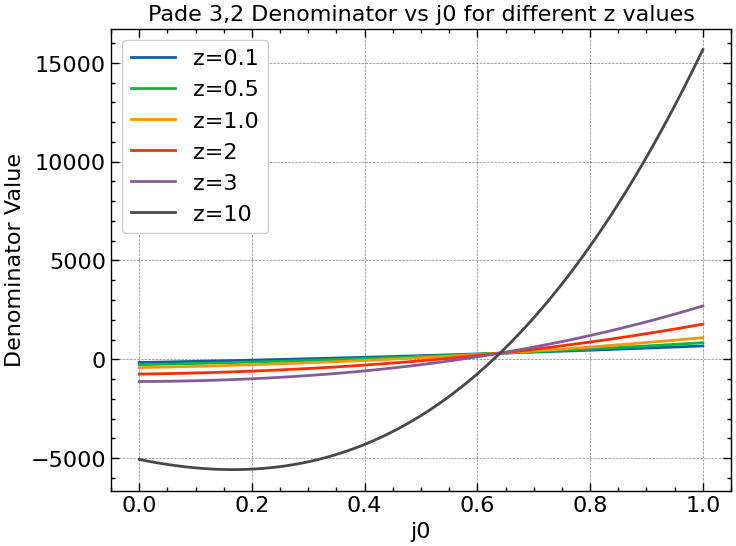

In [4]:
j0 =np.linspace(0,1,100)
for z in [0.1,0.5,1.0,2,3,10]:
    plt.plot(j0, pade_32_denominator(z=z,H0=70,q0=-0.6,j0=j0,s0 = -0.35,p0= -10, c0=3.11),label=f'z={z}')
plt.xlabel('j0')
plt.ylabel('Denominator Value')
plt.title('Pade 3,2 Denominator vs j0 for different z values')
plt.legend()

In [5]:
from itertools import combinations


In [6]:
z = np.linspace(0, 5, 1000)

# Parameter ranges

H0_range = np.linspace(60.0, 80.0,100)
q0_range = np.linspace(-2, 1, 100)
j0_range = np.linspace(-3, 4, 100)
s0_range = np.linspace(-5, 5, 100)
p0_range = np.linspace(-30, 10, 100)
c0_range = np.linspace(-10, 10, 100)
base = {"H0": 70.0, "q0": -0.55, "j0": 1.0, "s0": -0.35,'c0':3.11,'p0': -10.886749999999894}

# Use already defined ranges and avoid redundant computation
# Define parameter pairs for stability analysis
pairs = [
    ("q0", q0_range, "j0", j0_range),
    ("q0", q0_range, "s0", s0_range),
    ("q0", q0_range, "p0", p0_range),
    ("j0", j0_range, "s0", s0_range),
    ("j0", j0_range, "p0", p0_range),
    ("s0", s0_range, "p0", p0_range),
    
]



var_dict = {0: 'H0', 1: 'q0', 2: 'j0', 3: 's0', 4: 'c0', 5: 'p0'}

In [7]:
param_ranges = {
    
    "q0": q0_range,
    "j0": j0_range,
    "s0": s0_range,
    "p0": p0_range,
    "c0": c0_range,
}

# Base values remain exactly as you defined
base = {
    "H0": 70.0,
    "q0": -0.55,
    "j0": 1.0,
    "s0": -0.35,
    "c0": 3.11,
    "p0": -10.886749999999894,
}

# Automatically generate all unique pairs
pairs = [
    (p1, param_ranges[p1], p2, param_ranges[p2])
    for p1, p2 in combinations(param_ranges.keys(), 2)
]


In [17]:
pairs_pade_21 = [pairs[5]]

pairs_pade_32 = [
    ("q0", q0_range, "j0", j0_range),
    ("q0", q0_range, "s0", s0_range),
    ("q0", q0_range, "c0", c0_range),
    ("j0", j0_range, "s0", s0_range),
    ("j0", j0_range, "c0", c0_range),
    ("s0", s0_range, "c0", c0_range),
]



In [18]:
pairs_pade_32

[('q0',
  array([-2.        , -1.96969697, -1.93939394, -1.90909091, -1.87878788,
         -1.84848485, -1.81818182, -1.78787879, -1.75757576, -1.72727273,
         -1.6969697 , -1.66666667, -1.63636364, -1.60606061, -1.57575758,
         -1.54545455, -1.51515152, -1.48484848, -1.45454545, -1.42424242,
         -1.39393939, -1.36363636, -1.33333333, -1.3030303 , -1.27272727,
         -1.24242424, -1.21212121, -1.18181818, -1.15151515, -1.12121212,
         -1.09090909, -1.06060606, -1.03030303, -1.        , -0.96969697,
         -0.93939394, -0.90909091, -0.87878788, -0.84848485, -0.81818182,
         -0.78787879, -0.75757576, -0.72727273, -0.6969697 , -0.66666667,
         -0.63636364, -0.60606061, -0.57575758, -0.54545455, -0.51515152,
         -0.48484848, -0.45454545, -0.42424242, -0.39393939, -0.36363636,
         -0.33333333, -0.3030303 , -0.27272727, -0.24242424, -0.21212121,
         -0.18181818, -0.15151515, -0.12121212, -0.09090909, -0.06060606,
         -0.03030303,  0.     

In [10]:
# for ax, (p1, r1, p2, r2) in zip(axes.flatten(), pairs_pade_32):
#     Z = stability_map(r1, r2, base, p1, p2, z=np.array([z_val]), func=pade_32_denominator)

In [11]:
def stability_map(p1_vals, p2_vals, fixed, p1_name, p2_name,func = pade_21_denominator,z =z ):
    Z = np.zeros((len(p1_vals), len(p2_vals)))
    for i, p1 in enumerate(p1_vals):
        for j, p2 in enumerate(p2_vals):
            params = fixed.copy()
            params[p1_name] = p1
            params[p2_name] = p2
            denom = func(z, **params)
            Z[i, j] =denom
    return Z

In [12]:
Om_range_1 = np.linspace(0.0, 0.6, 500)
Om_range_2 = np.linspace(0.2, 0.4, 200)

H0,q0_range_1,j0_range_1,s0_range_1,c0_range_1,p0_range_1 = CosmographicTransforms.to_cosmographic(70, Om_range_1, 0.0, -1.0)
H0,q0_range_2,j0_range_2,s0_range_2,c0_range_2,p0_range_2 = CosmographicTransforms.to_cosmographic(70, Om_range_2, 0.0, -1.0)

base_range_1 = {
    "H0": H0_range,
    "q0": q0_range_1,
    "j0": j0_range_1,
    "s0": s0_range_1,
    "c0": c0_range_1,
    "p0": p0_range_1,
}
base_range_2 = {
    "H0": H0_range,
    "q0": q0_range_2,   
    "j0": j0_range_2,
    "s0": s0_range_2,
    "c0": c0_range_2,
    "p0": p0_range_2,
}




w_range_1 = np.linspace(-1.5,-0.5,200)
H0_w,q0_range_w,j0_range_w,s0_range_w,c0_range_w,p0_range_w = CosmographicTransforms.to_cosmographic(70, 0.3,0, w_range_1)
base_range_w = {
    "H0": H0_range,
    "q0": q0_range_w,
    "j0": j0_range_w,
    "s0": s0_range_w,
    "c0": c0_range_w,
    "p0": p0_range_w,
}

q0_range_w

Om_range_grid, w_range_grid = np.meshgrid(Om_range_1,w_range_1)

# plt.xlabel(r'$\Omega_m$')
# plt.ylabel(r'$w$')
# plt.xticks(np.linspace(0, Om_range_1.size - 1, 5), np.round(np.linspace(Om_range_1.min(), Om_range_1.max(), 5), 2))
# plt.yticks(np.linspace(0, w_range_1.size - 1, 5), np.round(np.linspace(w_range_1.min(), w_range_1.max(), 5), 2))
# plt.imshow(CosmographicTransforms.to_cosmographic(70, Om_range_grid, 0.0, w_range_grid)[1])
# plt.colorbar(label='q0')

In [13]:
# import glob 
# for file in glob.glob('plot_*.csv'):
#     df_temp = pd.read_csv(file, header=None)
#     filename = file.replace('plot_', 'boundary_').replace('.csv', '_om_0_6.npy')
#     np.save(filename, np.array([df_temp[0], df_temp[1]]))


In [14]:
# om_range_1 = np.linspace(0.2, 0.4, 500)
# w_range_1 = np.linspace(-2,0,500)  
# om_range_2 = np.linspace(0.2, 0.4, 1000)
# w_range_2 = np.linspace(-1.5,-0.4,1000)
# om_range_3 = np.linspace(0.27, 0.33, 100)
# w_range_3 = np.linspace(-1.2,-0.8,100)
# fig, axes = plt.subplots(5, 2, figsize=(12, 22), constrained_layout=True)
# for ax,(i,j) in zip(axes.flatten(),list(combinations([1,2,3,4,5], 2))):
#         for ix in range(2,3):
#                   om_range_grid, w_range_grid = np.meshgrid(eval(f'om_range_{ix}'),eval(f'w_range_{ix}'))       
#                   x = CosmographicTransforms.to_cosmographic(70, om_range_grid, 0.0, w_range_grid)[i].flatten()
#                   y = CosmographicTransforms.to_cosmographic(70, om_range_grid, 0.0, w_range_grid)[j].flatten()
#                   H, xedges, yedges = np.histogram2d(y, x, bins=(300, 300))
#                   H_mask = H.T > 0  # Mask where there's data
               


#                   ax.plot(y,x,',', label=f'$\Omega_m$: [{om_range_grid.min():.2f}, {om_range_grid.max():.2f}], w: [{w_range_grid.min():.2f}, {w_range_grid.max():.2f}]', markersize=0.5, alpha=0.01)
#                   ax.imshow(H_mask, extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
#                         origin='lower', cmap='Greys', alpha=0.5, aspect='auto')
#         ax.plot(base[var_dict[j]], base[var_dict[i]], 'r*', label='Base Model', markersize=8)
#         ax.set_xlabel(var_dict[i])
#         ax.set_ylabel(var_dict[j])
#         ax.legend()

# plt.show()


KeyboardInterrupt: 

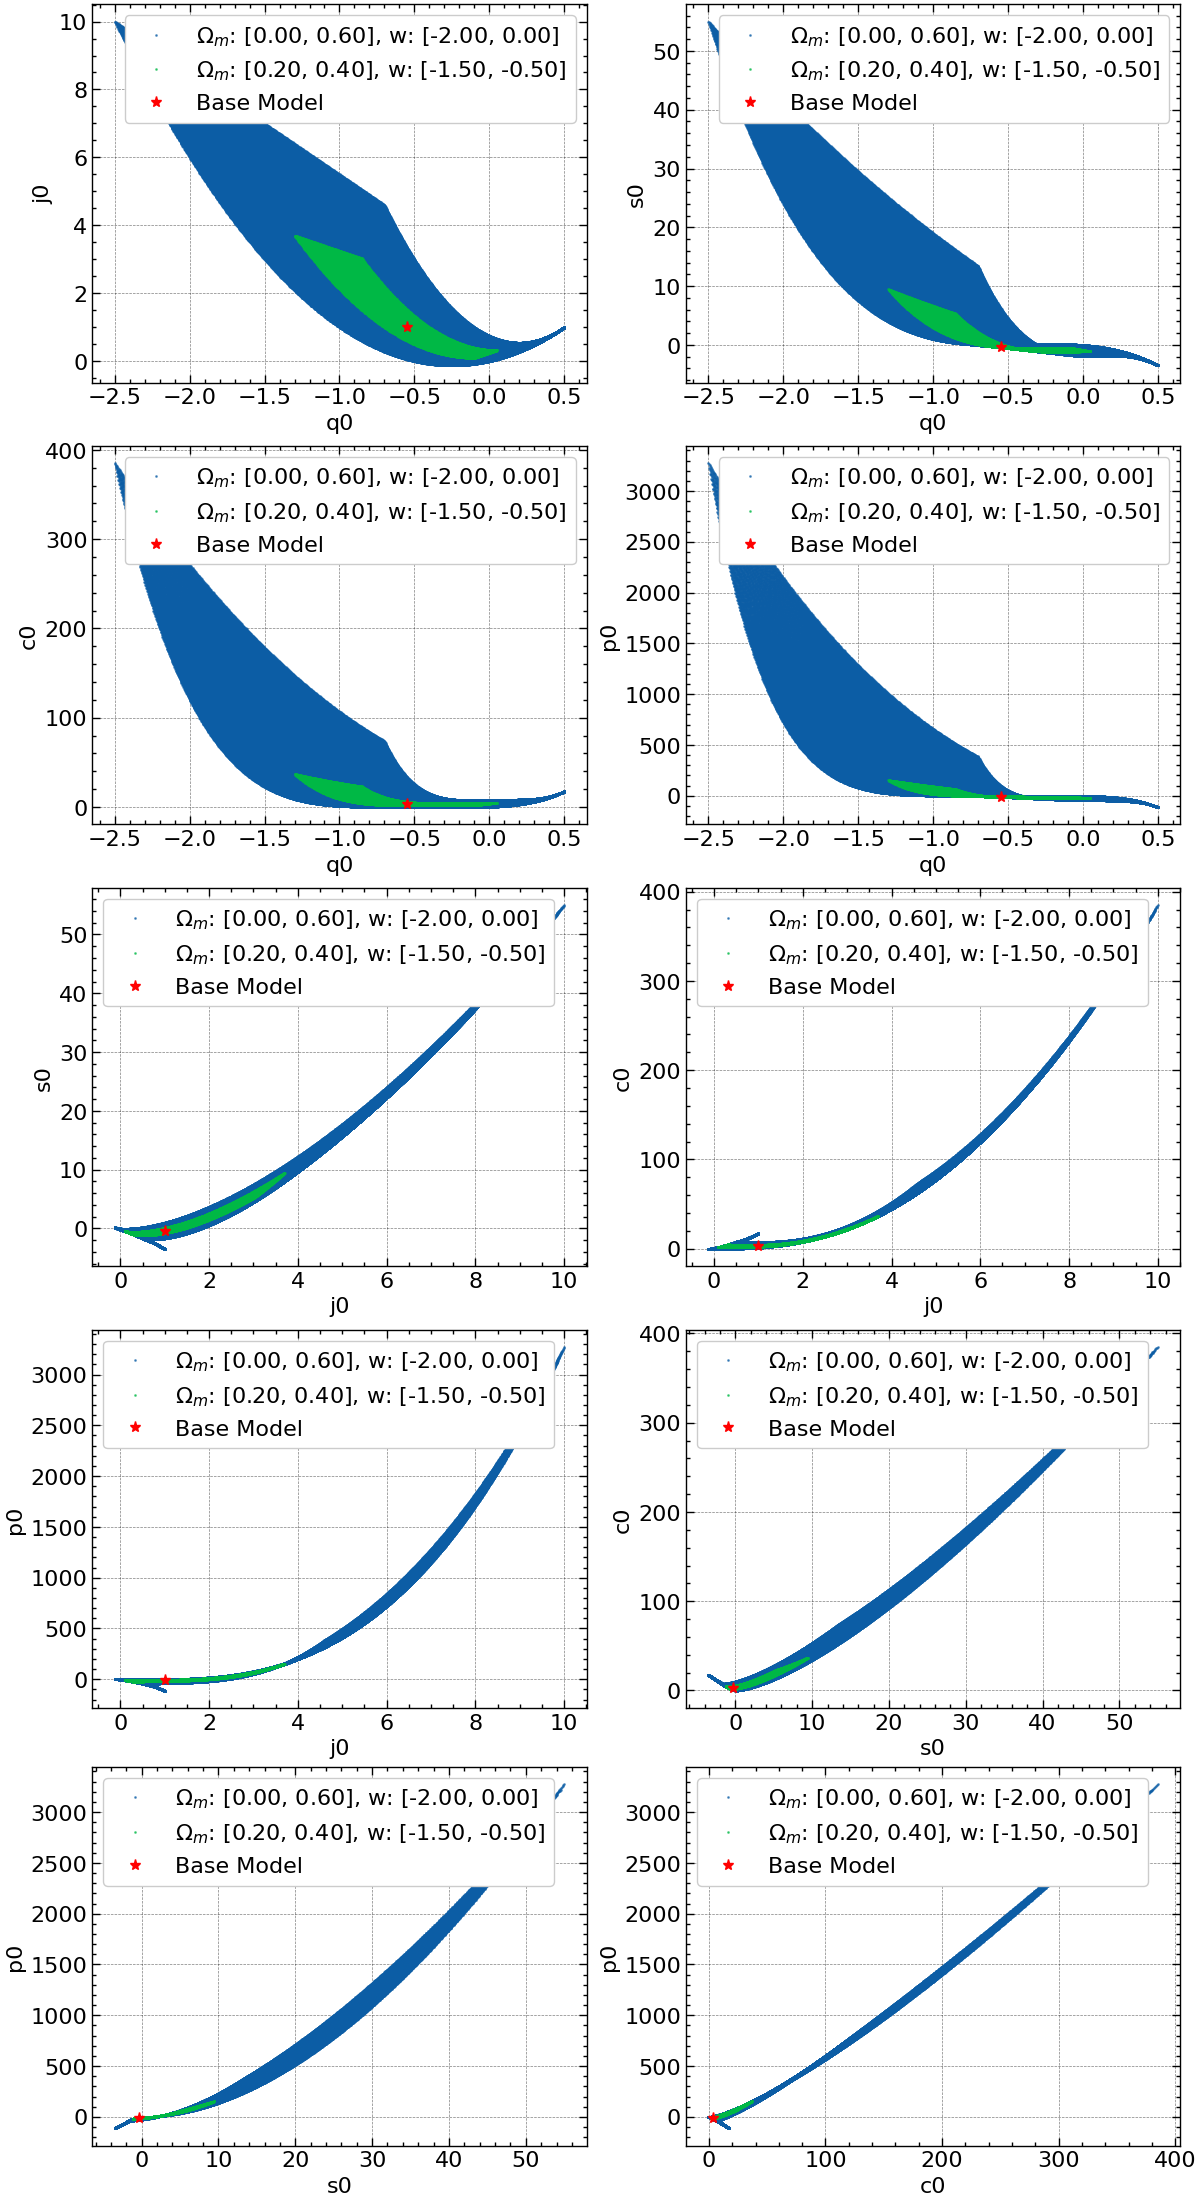

In [15]:
om_range_1 = np.linspace(0.0, 0.6, 500)
w_range_1 = np.linspace(-2,0,500)  
om_range_2 = np.linspace(0.2, 0.4, 200)
w_range_2 = np.linspace(-1.5,-0.5,200)
om_range_3 = np.linspace(0.27, 0.33, 100)
w_range_3 = np.linspace(-2,0,100)
fig, axes = plt.subplots(5, 2, figsize=(12, 22), constrained_layout=True)
for ax,(i,j) in zip(axes.flatten(),list(combinations([1,2,3,4,5], 2))):
        for ix in range(1,3):
                  om_range_grid, w_range_grid = np.meshgrid(eval(f'om_range_{ix}'),eval(f'w_range_{ix}'))       
                  x = CosmographicTransforms.to_cosmographic(70, om_range_grid, 0.0, w_range_grid)[i].flatten()
                  y = CosmographicTransforms.to_cosmographic(70, om_range_grid, 0.0, w_range_grid)[j].flatten()
                  ax.plot(x,y,'.', label=f'$\Omega_m$: [{om_range_grid.min():.2f}, {om_range_grid.max():.2f}], w: [{w_range_grid.min():.2f}, {w_range_grid.max():.2f}]', markersize=2, alpha=0.6)
        
        ax.plot(base[var_dict[i]], base[var_dict[j]], 'r*', markersize=8, label='Base Model')
        ax.set_xlabel(var_dict[i])
        ax.set_ylabel(var_dict[j])
        ax.legend()

plt.show()

In [ ]:
# from itertools import combinations
# import alphashape

# for i, j in combinations([1, 2, 3, 4, 5], 2):
#     fig, ax = plt.subplots(figsize=(8, 8))
    
#     x = CosmographicTransforms.to_cosmographic(70, Om_range_grid, 0.0, w_range_grid)[i].flatten()
#     y = CosmographicTransforms.to_cosmographic(70, Om_range_grid, 0.0, w_range_grid)[j].flatten()
    
#     # Plot scatter points
#     ax.plot(x, y, '.', alpha=1, markersize=2)
    
#     # Calculate and plot alphashape boundary
#     points = np.column_stack([x, y])
#     alpha_shape = alphashape.alphashape(points, 3)
#     ax.set_xlabel(f'{var_dict[i]}')
#     ax.set_ylabel(f'{var_dict[j]}')
#     ax.plot(base[var_dict[i]], base[var_dict[j]], '*', color='magenta', markersize=8, label=r'$\Lambda$ CDM value')

#     if hasattr(alpha_shape, 'exterior'):
#         boundary = alpha_shape.exterior.coords.xy
#         ax.plot(boundary[0], boundary[1], 'r-', linewidth=2)
#         print('For combination', (i, j))
#         boundary_x = np.array(boundary[0])
#         boundary_y = np.array(boundary[1])
#         print(f"\nContour for combination ({i}, {j}):")
#         print(f"X coordinates shape: {boundary_x.shape}")
#         print(f"Y coordinates shape: {boundary_y.shape}")
#         print(f"X: {boundary_x}")
#         print(f"Y: {boundary_y}")
#         np.save(f'boundary_{i}_{j}.npy', np.array([boundary_x, boundary_y]))
    
#     plt.savefig(f'alphashape_boundary_{i}_{j}_boudnary.png')

In [ ]:
# from itertools import combinations
# import alphashape

# fig, axes = plt.subplots(5, 2, figsize=(12, 22), constrained_layout=True)

# for ax, (i, j) in zip(axes.flatten(), list(combinations([1, 2, 3, 4, 5], 2))):
#     x = CosmographicTransforms.to_cosmographic(70, Om_range_grid, 0.0, w_range_grid)[i].flatten()
#     y = CosmographicTransforms.to_cosmographic(70, Om_range_grid, 0.0, w_range_grid)[j].flatten()
    
#     # Plot scatter points
#     ax.plot(x, y, '.', alpha=0.6, markersize=2)
    
#     # Calculate and plot alphashape boundary with optimized alpha
#     points = np.column_stack([x, y])
    
#     try:
#         # Use alphashape.optimizealpha to find best alpha automatically
#         alpha_opt = alphashape.optimizealpha(points)
#         alpha_shape = alphashape.alphashape(points, alpha=alpha_opt)
        
#         if hasattr(alpha_shape, 'exterior'):
#             boundary = alpha_shape.exterior.coords.xy
#             ax.plot(boundary[0], boundary[1], 'r-', linewidth=2)
#         elif hasattr(alpha_shape, 'geoms'):
#             for geom in alpha_shape.geoms:
#                 if hasattr(geom, 'exterior'):
#                     boundary = geom.exterior.coords.xy
#                     ax.plot(boundary[0], boundary[1], 'r-', linewidth=2)
#     except:
#         # Fallback: manually tune alpha
#         alpha_shape = alphashape.alphashape(points, alpha=0.1)
#         if hasattr(alpha_shape, 'exterior'):
#             boundary = alpha_shape.exterior.coords.xy
#             ax.plot(boundary[0], boundary[1], 'r-', linewidth=2)

# plt.show()

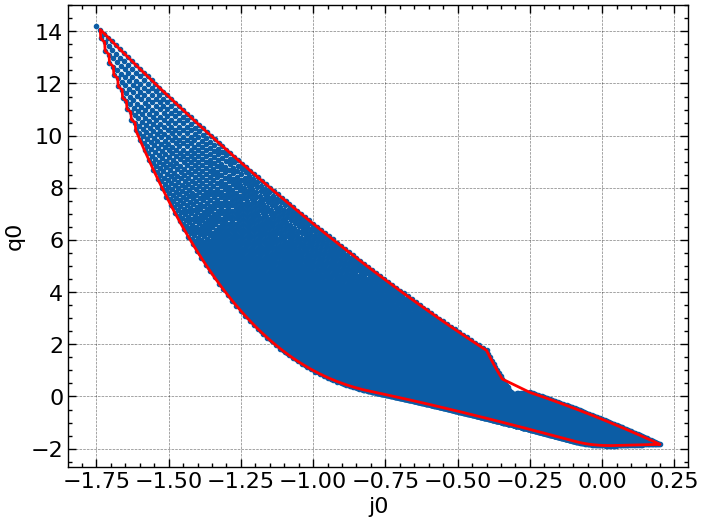

In [ ]:

# from scipy.spatial import ConvexHull

# import alphashape
# alpha = 0.5


# x = CosmographicTransforms.to_cosmographic(70, Om_range_grid, 0.0, w_range_grid)[1].flatten()
# y = CosmographicTransforms.to_cosmographic(70, Om_range_grid, 0.0, w_range_grid)[3].flatten()

# plt.plot(x,y,'.')
# points = np.column_stack([x,y
# ])
# hull = ConvexHull(points)


# # for simplex in hull.simplices:
# #     plt.plot(points[simplex, 1], points[simplex, 0], 'k-')
# plt.xlabel('j0')
# plt.ylabel('q0')


# shape = alphashape.alphashape(points, alpha)
# bx, by = shape.exterior.xy
# plt.plot(bx, by, color='red')

AttributeError: 'MultiPolygon' object has no attribute 'exterior'

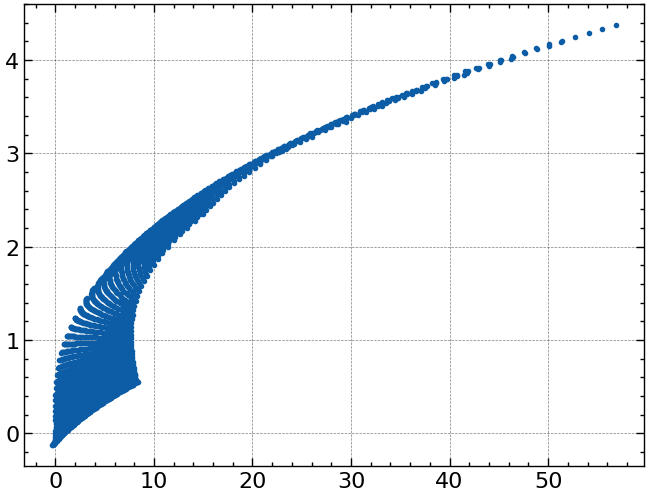

In [ ]:
# from shapely.geometry import Point, MultiPoint
# from shapely.ops import unary_union, polygonize
# import alphashape
# alpha = 3

# x = CosmographicTransforms.to_cosmographic(70, Om_range_grid, 0.0, w_range_grid)[4].flatten()
# y = CosmographicTransforms.to_cosmographic(70, Om_range_grid, 0.0, w_range_grid)[2].flatten()

# points = np.column_stack([x,y])
# plt.plot(x,y,'.')

# shape = alphashape.alphashape(points, alpha)
# if shape.geom_type == 'MultiPolygon':
#     shape = unary_union(shape)

# bx, by = shape.exterior.xy
# plt.plot(bx, by, color='red')

In [ ]:
# from sklearn.neighbors import NearestNeighbors
# from shapely.geometry import MultiPoint, Polygon
# import numpy as np

# def concave_hull(points, k):
#     if k < 3:
#         raise ValueError("k must be >= 3")

#     pts = np.array(points)
#     hull = MultiPoint(pts).convex_hull  # start convex

#     while True:
#         # compute concave hull with knn
#         nbrs = NearestNeighbors(n_neighbors=k).fit(pts)
#         distances, _ = nbrs.kneighbors(pts)
#         max_dist = np.max(distances)
#         new_hull = MultiPoint(pts).buffer(max_dist).intersection(hull.buffer(0))

#         if new_hull.equals(hull):
#             break
#         hull = new_hull

#     return hull
# concave_hull(points, k=10)


In [ ]:
# shape = concave_hull(points, k=10)
# bx, by = shape.exterior.xy
# plt.plot(bx, by, 'r')

In [ ]:


# Create directory structure
os.makedirs("Denominator plots/pade_21", exist_ok=True)

for z_val in np.linspace(0.01, 5, 10):
    fig, axes = plt.subplots(1, 1, figsize=(10, 10), constrained_layout=True)

    for ax, (p1, r1, p2, r2) in zip([axes], pairs_pade_21):
        Z = stability_map(r1, r2, base, p1, p2, z=np.array([z_val]))
        norm = TwoSlopeNorm(vmin=Z.min(), vcenter=0.0, vmax=max(Z.max(), 1e-5))
        img = ax.imshow(Z, origin="lower", aspect="auto", norm=norm, cmap="seismic",
                        extent=[r2.min(), r2.max(), r1.min(), r1.max()])
        ax.contour(r2, r1, Z, levels=[0], colors='k', linewidths=2)
        ax.plot(base[p2], base[p1], '*', color='magenta', markersize=8, label=r'$\Lambda$ CDM value')
        ax.set_xlabel(p2)
        ax.plot(base_range_1[p2],base_range_1[p1],color='lime',label = 'Variation around $\Omega_m$: 0.0-0.6')
        ax.plot(base_range_2[p2],base_range_2[p1],color='orange',label = 'Variation around $\Omega_m$: 0.2-0.4')
        ax.plot(base_range_w[p2],base_range_w[p1],color='cyan',label = 'Variation around w: -1.5 to -0.5')
        ax.set_ylabel(p1)
        ax.set_title(f"{p1} vs {p2} for z={z_val:.2f}")
        ax.legend()
    fig.colorbar(img, ax=axes, orientation='vertical', fraction=0.02, pad=0.02, label="D(z) (white = 0 line)")
    plt.suptitle(f"Stability heatmaps: Denominator for Pade 2,1 D(z) at z={z_val:.2f}")
    
    # Save the plot
    plt.savefig(f"Denominator plots/pade_21/pade_21_z_{z_val:.2f}.png", dpi=150, bbox_inches='tight')
    #plt.show()
    
    #plt.close()
    plt.close()

/tmp/ipykernel_62517/3276091039.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z[i, j] =denom


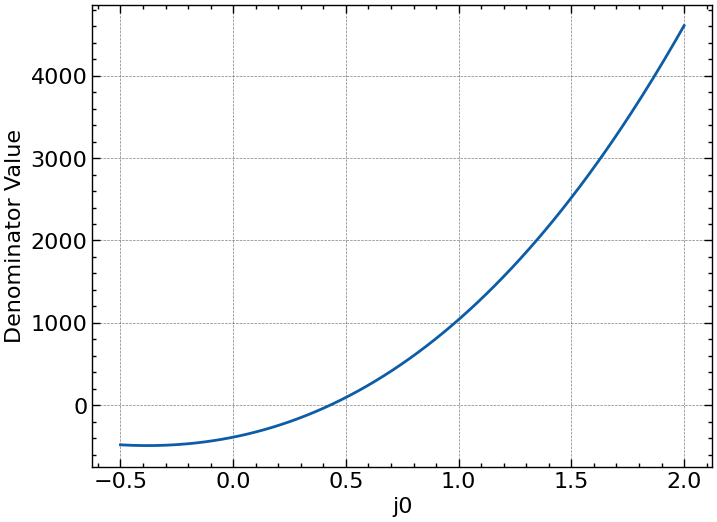

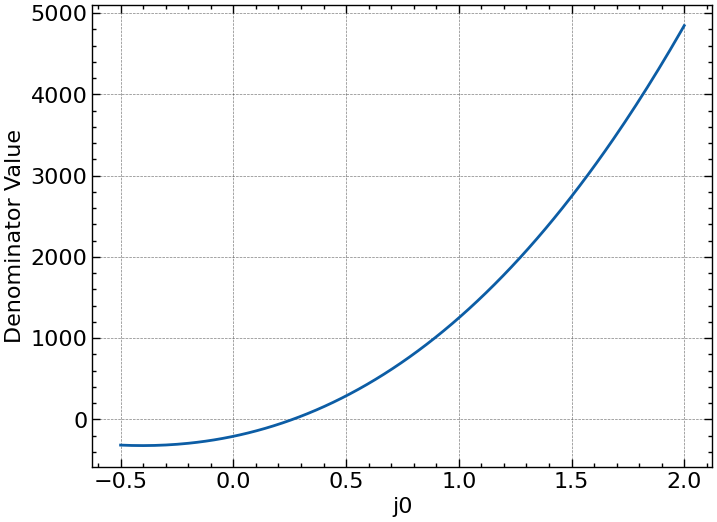

In [ ]:
plt.plot(np.linspace(-0.5,2,200), pade_32_denominator(H0=70.0, q0=-0.6, j0=np.linspace(-0.5,2,200), s0 = -0.35, c0=3.11, p0=-10.886749999999894, z=np.array([0.9]) ))
plt.xlabel('j0')
plt.ylabel('Denominator Value')


plt.show()
plt.plot(np.linspace(-0.5,2,200), pade_32_denom_GPT(H0=70.0, q0=-0.6, j0=np.linspace(-0.5,2,200), s0=-0.35, l0=0, p0=0, z=np.array([0.9]) ))
plt.xlabel('j0')
plt.ylabel('Denominator Value')
plt.show()

In [19]:
var_dict_inv = {v: k for k, v in var_dict.items()}
om_range = np.linspace(0.2, 0.4, 700)
w_range = np.linspace(-1.5,-0.5,700)

om_range_grid, w_range_grid = np.meshgrid(om_range,w_range)

In [ ]:
base

/tmp/ipykernel_102963/3276091039.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z[i, j] =denom


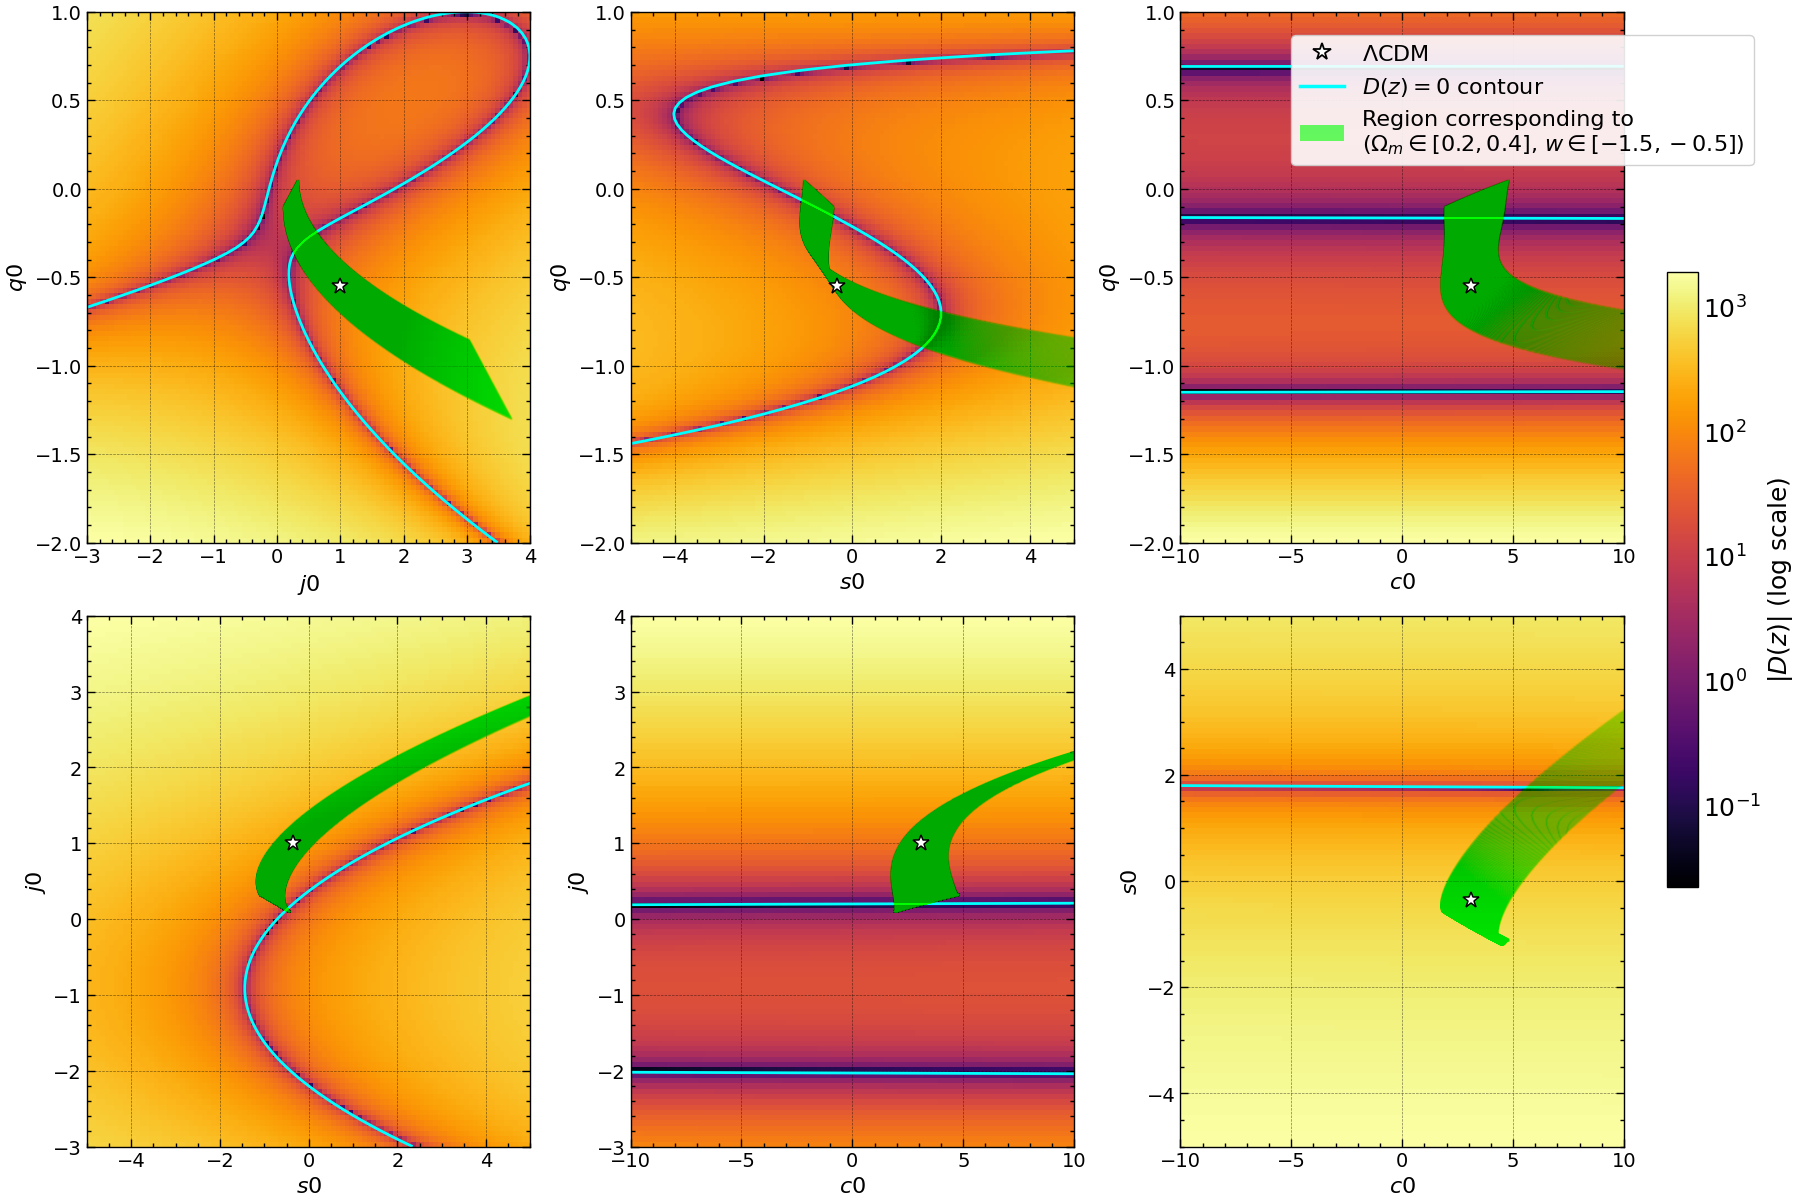

/tmp/ipykernel_102963/3276091039.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z[i, j] =denom


In [ ]:
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm
from matplotlib.patches import Patch
import numpy as np

# Create directory structure
os.makedirs("Denominator plots/pade_32", exist_ok=True)

for z_val in [0.01, 0.1, 1]:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12), constrained_layout=True)

    for ax, (p1, r1, p2, r2) in zip(axes.flatten(), pairs_pade_32):
        Z = stability_map(r1, r2, base, p1, p2, z=np.array([z_val]), func=pade_32_denominator)
        
        # Use LogNorm for logarithmic color scaling
        Z_abs = np.abs(Z) + 1e-10
        norm = LogNorm(vmin=Z_abs.min(), vmax=Z_abs.max())
        
        img = ax.imshow(Z_abs, origin="lower", aspect="auto", norm=norm, cmap="inferno",
                        extent=[r2.min(), r2.max(), r1.min(), r1.max()])
        
        # Zero contour with higher contrast
        ax.contour(r2, r1, Z, levels=[0], colors='cyan', linewidths=2, linestyles='-')
        
        # Physical region
        x = CosmographicTransforms.to_cosmographic(70, om_range_grid, 0.0, w_range_grid)[var_dict_inv[p1]].flatten()
        y = CosmographicTransforms.to_cosmographic(70, om_range_grid, 0.0, w_range_grid)[var_dict_inv[p2]].flatten()
        ax.plot(y, x, '.', color='lime', alpha=0.01, markersize=1.5, rasterized=True)

        # Lambda CDM marker
        ax.plot(base[p2], base[p1], marker='*', color='white', markersize=12, 
                markeredgecolor='black', markeredgewidth=1.1, zorder=10)
        
        # Labels with larger font
        ax.set_xlabel(f'${p2}$', fontsize=16)
        ax.set_ylabel(f'${p1}$', fontsize=16)
        ax.tick_params(labelsize=14)
        ax.set_xlim(r2.min(), r2.max())
        ax.set_ylim(r1.min(), r1.max())
    
    # Custom legend
    legend_elements = [
        Line2D([0], [0], marker='*', color='w', markerfacecolor='white', 
               markeredgecolor='black', markeredgewidth=1.3, markersize=13, 
               label=r'$\Lambda$CDM', linestyle='None'),
        Line2D([0], [0], color='cyan', linewidth=2.5, label=r'$D(z)=0$ contour'),
        Patch(facecolor='lime', alpha=0.6, 
              label='Region corresponding to \n'  
              r'($\Omega_m \in [0.2, 0.4]$, $w \in [-1.5, -0.5]$)')
    ]
    fig.legend(handles=legend_elements, loc='upper right', fontsize=16, framealpha=0.9, bbox_to_anchor=(0.98, 0.98))

    # Colorbar
    cbar = fig.colorbar(img, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
    cbar.set_label(r'$|D(z)|$ (log scale)', fontsize=18)
    cbar.ax.tick_params(labelsize=18)
    
    # Title
    #fig.suptitle(f'Padé (3,2) Denominator Stability at $z={z_val}$', fontsize=16, y=0.995)
    
    # plt.savefig(f"Denominator plots/pade_32/pade_32_z_{z_val:.2f}_publication.png", 
    #             dpi=300, bbox_inches='tight')
    plt.savefig(f"Denominator plots/pade_32/pade_32_z_{z_val:.2f}_w_om.pdf", 
                bbox_inches='tight',dpi=300)
    plt.show()
    plt.close()    #axes.flatten()[2].legend(handles=legend_elements, loc='upper right', fontsize=16, framealpha=0.9)


In [ ]:
Z = stability_map(r1, r2, base, p1, p2, z=np.array([z_val]), func=pade_42_denominator)
        

TypeError: pade_42_denominator() missing 1 required positional argument: 'H0'

/tmp/ipykernel_28491/3276091039.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z[i, j] =denom


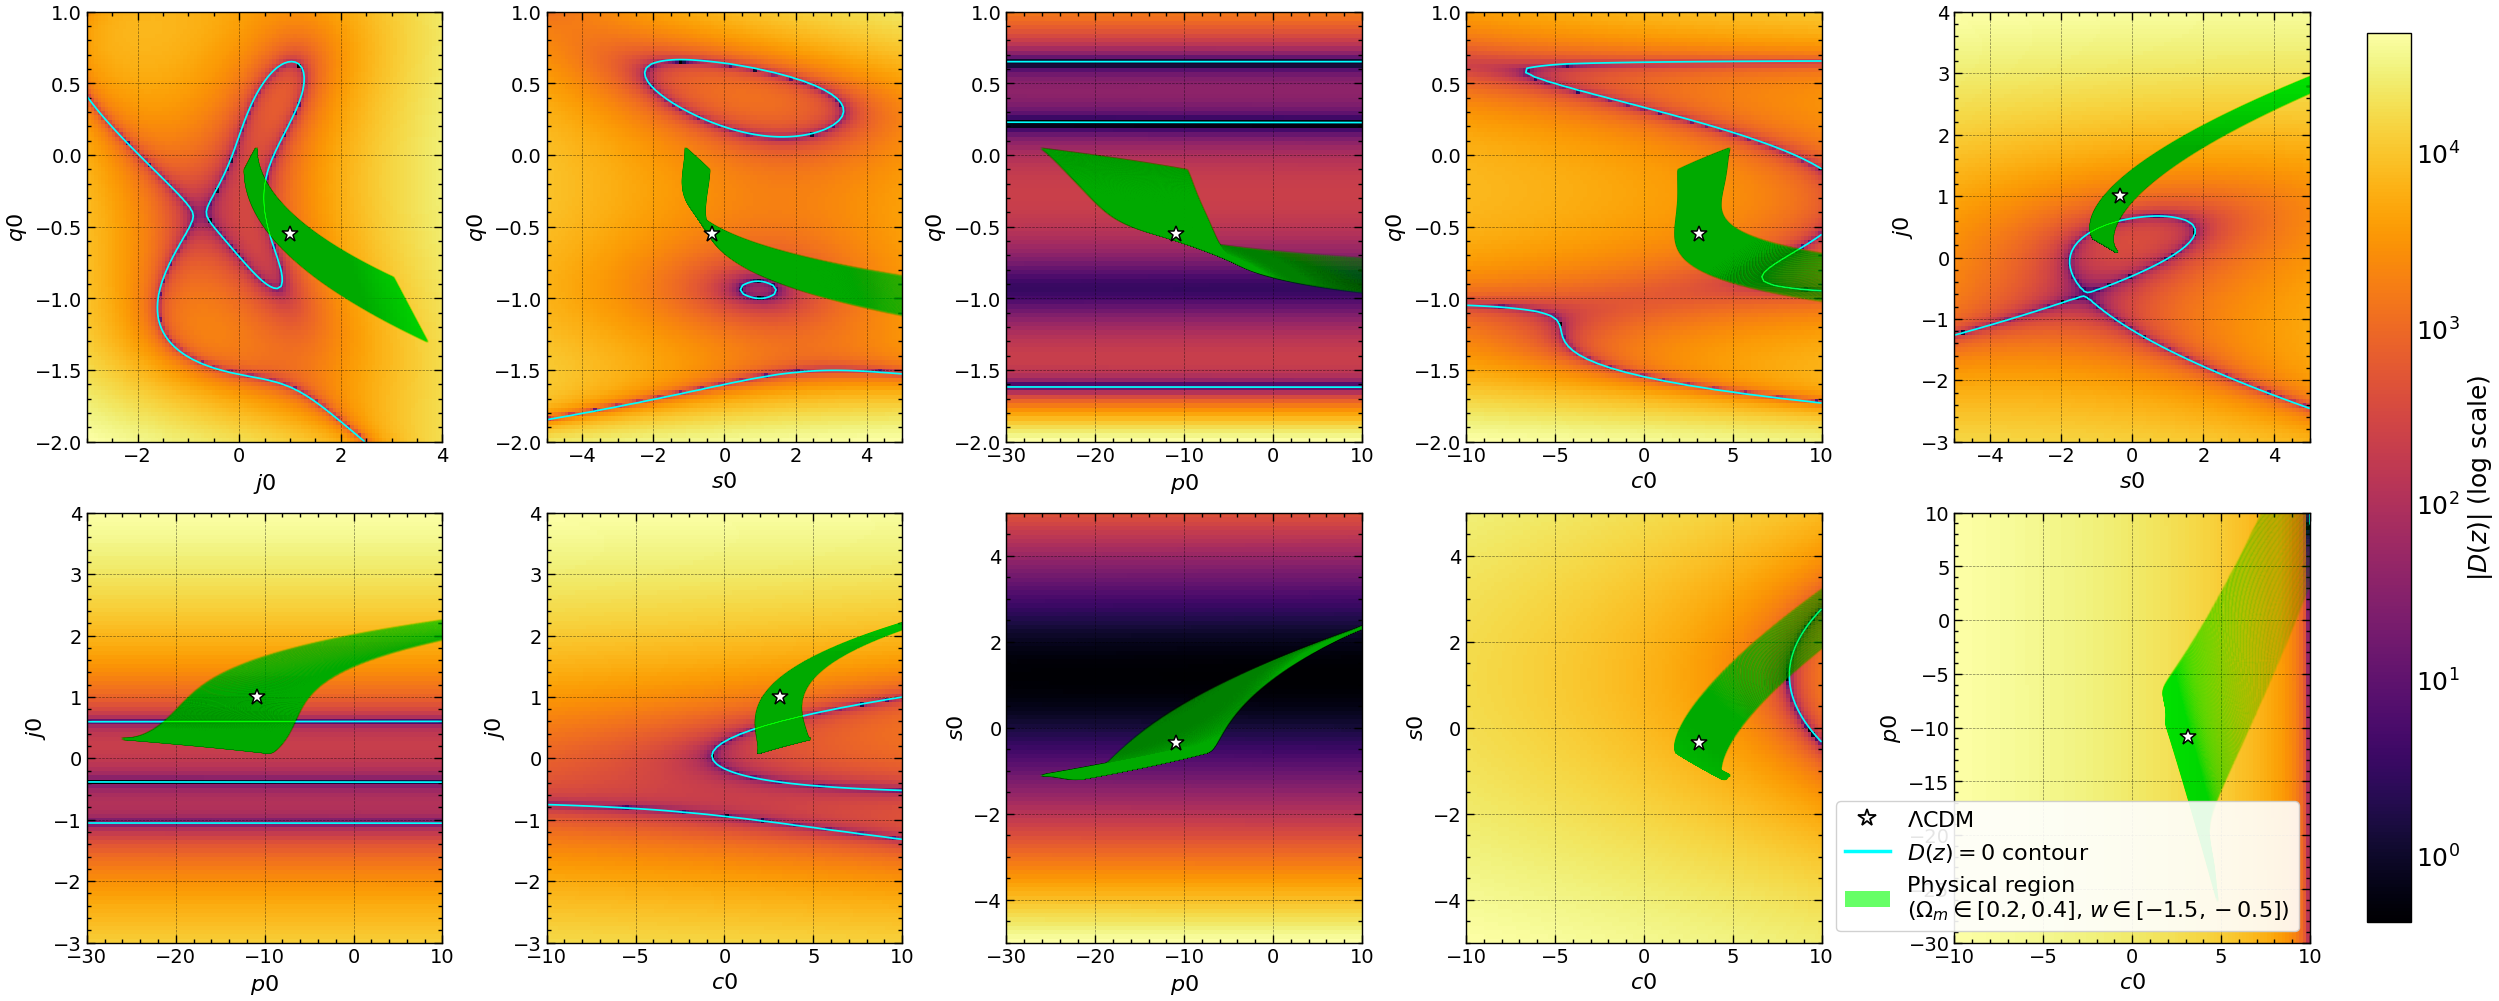

/tmp/ipykernel_28491/3276091039.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z[i, j] =denom


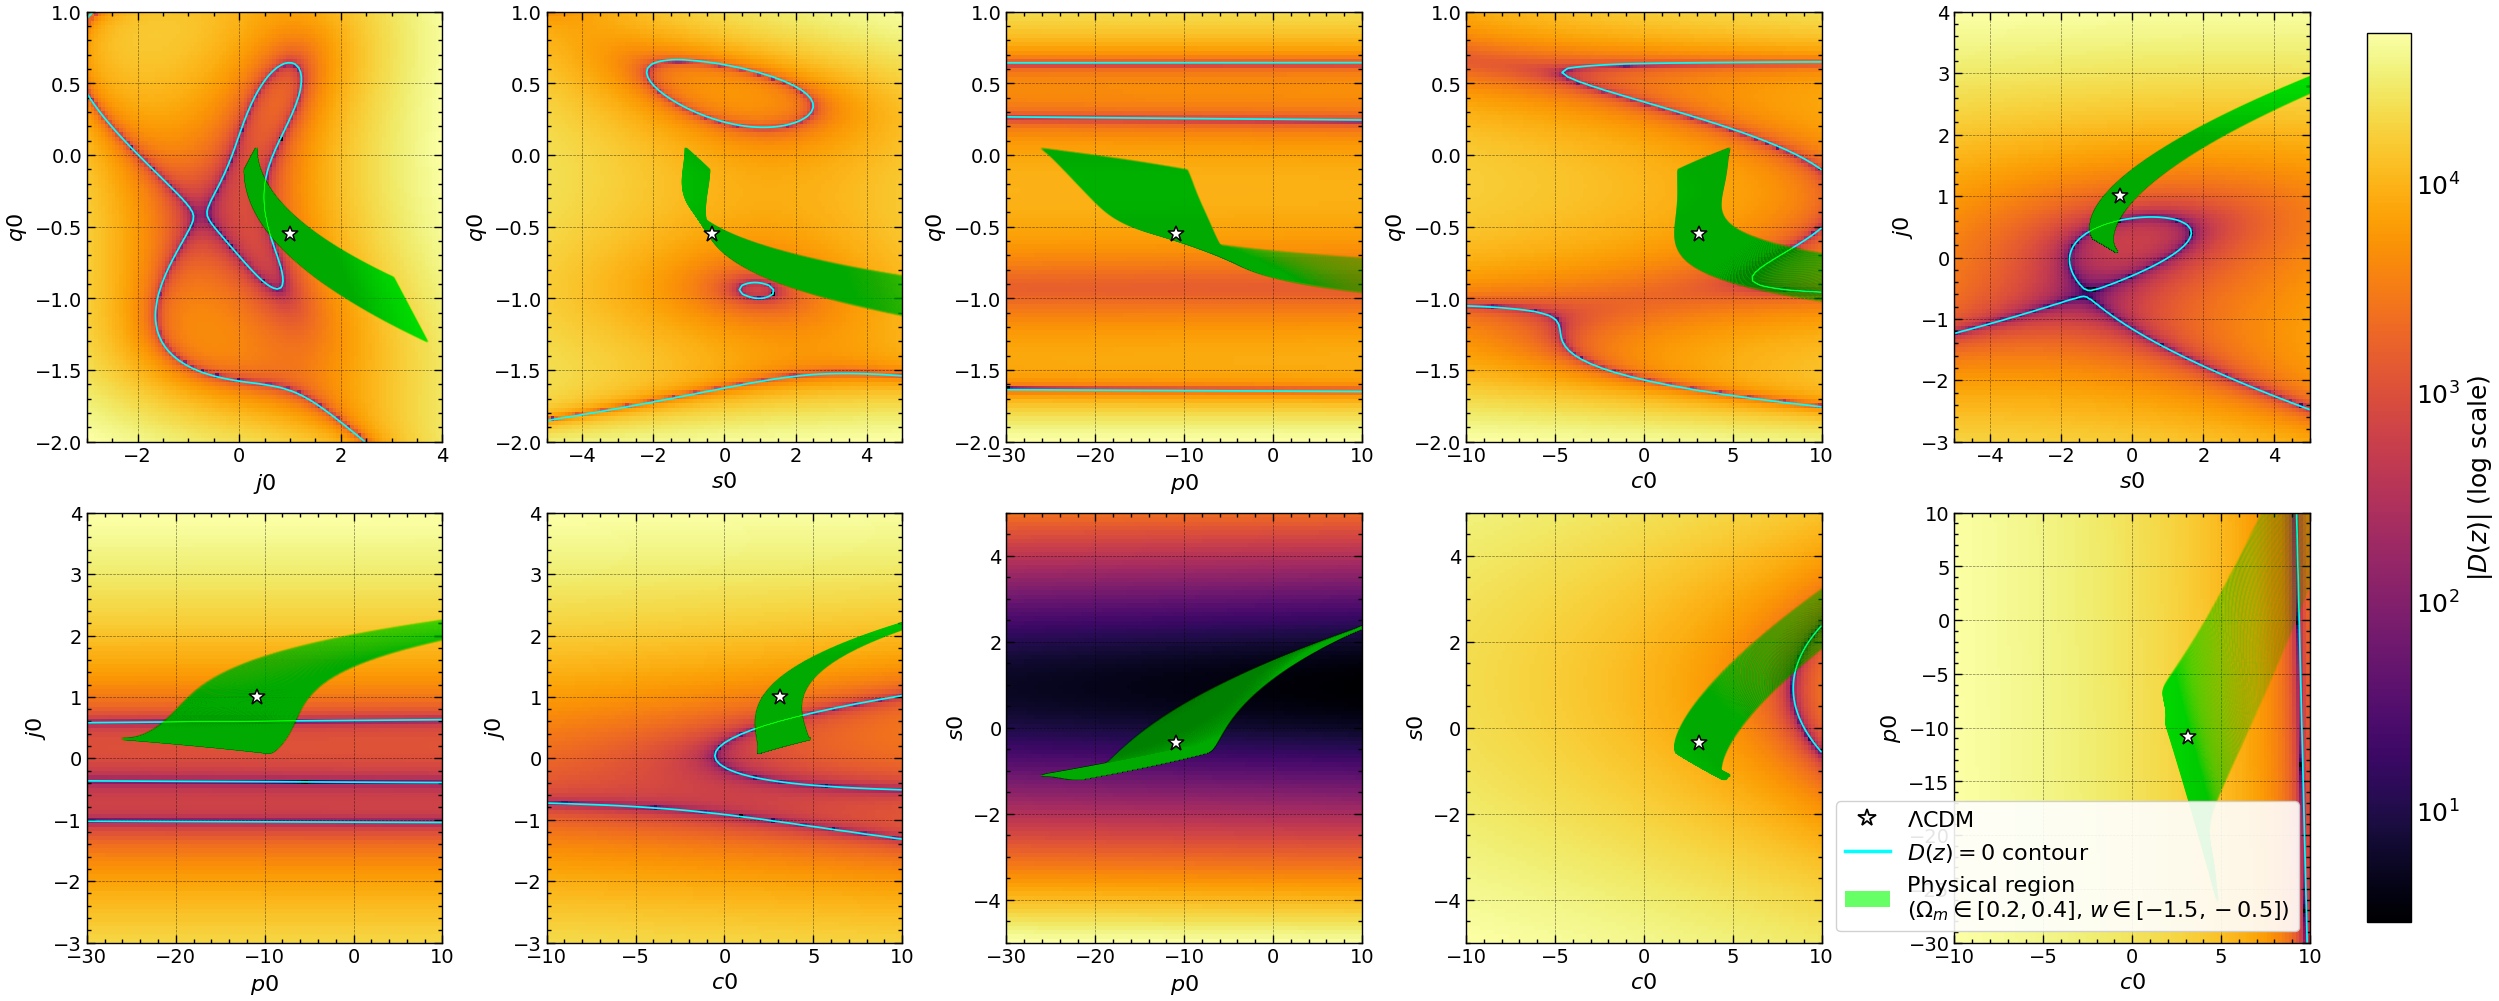

/tmp/ipykernel_28491/3276091039.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z[i, j] =denom


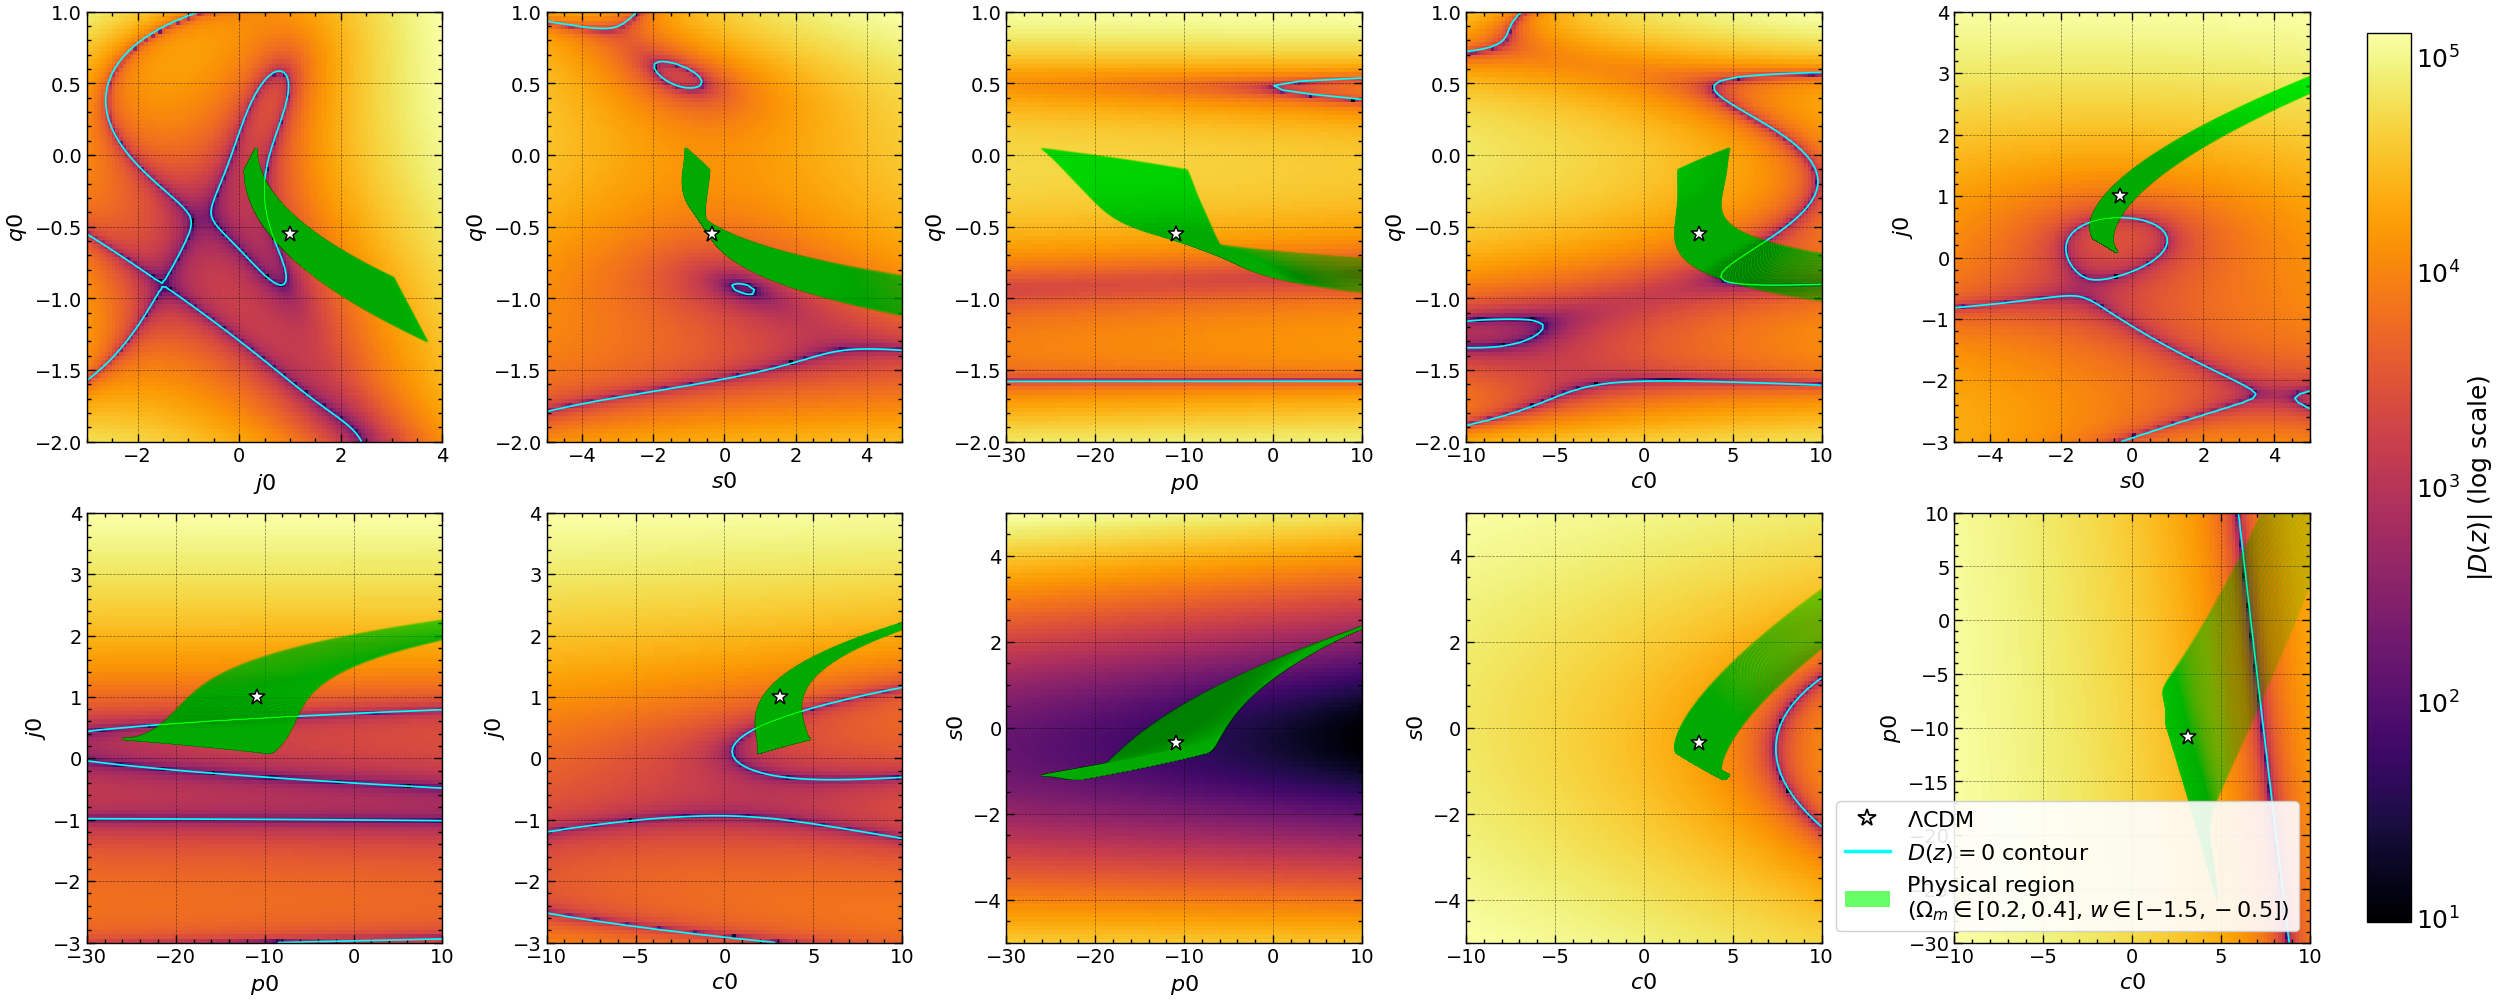

In [ ]:


# Create directory structure
os.makedirs("Denominator plots/pade_42", exist_ok=True)

# for z_val in np.linspace(0.01, 5, 10):
#     fig, axes = plt.subplots(5, 3, figsize=(20, 25), constrained_layout=True)

#     for ax, (p1, r1, p2, r2) in zip(axes.flatten(), pairs):
#         Z = stability_map(r1, r2, base, p1, p2, z=np.array([z_val]),func = pade_42_denominator)
#         norm = TwoSlopeNorm(vmin=min(Z.min(),-1e-5), vcenter=0.0, vmax=max(Z.max(), 1e-5))
#         img = ax.imshow(Z, origin="lower", aspect="auto", norm=norm, cmap="seismic",
#                         extent=[r2.min(), r2.max(), r1.min(), r1.max()])
#         ax.contour(r2, r1, Z, levels=[0], colors='k', linewidths=2)
#         ax.plot(base[p2], base[p1], '*', color='magenta', markersize=8, label=r'$\Lambda$ CDM value')

#         ax.plot(base_range_1[p2],base_range_1[p1],color='lime',label = 'Variation around $\Omega_m$: 0.0-0.6')
#         ax.plot(base_range_2[p2],base_range_2[p1],color='orange',label = 'Variation around $\Omega_m$: 0.2-0.4')
#         ax.plot(base_range_w[p2],base_range_w[p1],color='cyan',label = 'Variation around w: -1.5 to -0.5')  
#         ax.set_xlabel(p2)
#         ax.set_ylabel(p1)
#         ax.set_title(f"{p1} vs {p2} for z={z_val:.2f}")
#         ax.legend()
#     fig.colorbar(img, ax=axes, orientation='vertical', fraction=0.02, pad=0.02, label="D(z) (white = 0 line)")
#     plt.suptitle(f"Stability heatmaps: Denominator for Pade 4,2 D(z) at z={z_val:.2f}")
    
#     # Save the plot
#     plt.savefig(f"Denominator plots/pade_42/pade_42_z_{z_val:.2f}.png", dpi=150, bbox_inches='tight')
#     #plt.show()
#     plt.close()
#     #plt.close()



for z_val in [0.01, 0.1, 1]:
    fig, axes = plt.subplots(2, 5, figsize=(25, 10), constrained_layout=True)

    for ax, (p1, r1, p2, r2) in zip(axes.flatten(), pairs):
        Z = stability_map(r1, r2, base, p1, p2, z=np.array([z_val]), func=pade_42_denominator)
        
        # Use LogNorm for logarithmic color scaling
        Z_abs = np.abs(Z) + 1e-10
        norm = LogNorm(vmin=Z_abs.min(), vmax=Z_abs.max())
        
        img = ax.imshow(Z_abs, origin="lower", aspect="auto", norm=norm, cmap="inferno",
                        extent=[r2.min(), r2.max(), r1.min(), r1.max()])
        
        # Zero contour with higher contrast
        ax.contour(r2, r1, Z, levels=[0], colors='cyan', linewidths=1.25, linestyles='-')
        
        # Physical region
        x = CosmographicTransforms.to_cosmographic(70, om_range_grid, 0.0, w_range_grid)[var_dict_inv[p1]].flatten()
        y = CosmographicTransforms.to_cosmographic(70, om_range_grid, 0.0, w_range_grid)[var_dict_inv[p2]].flatten()
        ax.plot(y, x, '.', color='lime', alpha=0.01, markersize=1.5, rasterized=True)

        # Lambda CDM marker
        ax.plot(base[p2], base[p1], marker='*', color='white', markersize=12, 
                markeredgecolor='black', markeredgewidth=1.1, zorder=10)
        
        # Labels with larger font
        ax.set_xlabel(f'${p2}$', fontsize=16)
        ax.set_ylabel(f'${p1}$', fontsize=16)
        ax.tick_params(labelsize=14)
        ax.set_xlim(r2.min(), r2.max())
        ax.set_ylim(r1.min(), r1.max())
    
    # Custom legend
    legend_elements = [
        Line2D([0], [0], marker='*', color='w', markerfacecolor='white', 
               markeredgecolor='black', markeredgewidth=1.3, markersize=13, 
               label=r'$\Lambda$CDM', linestyle='None'),
        Line2D([0], [0], color='cyan', linewidth=2.5, label=r'$D(z)=0$ contour'),
        Patch(facecolor='lime', alpha=0.6, 
              label='Physical region\n'  
              r'($\Omega_m \in [0.2, 0.4]$, $w \in [-1.5, -0.5]$)')
    ]
    axes.flatten()[-1].legend(handles=legend_elements, loc='lower right', fontsize=16, framealpha=0.9)

    # Colorbar
    cbar = fig.colorbar(img, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
    cbar.set_label(r'$|D(z)|$ (log scale)', fontsize=18)
    cbar.ax.tick_params(labelsize=18)
    
    # Title
    #fig.suptitle(f'Padé (3,2) Denominator Stability at $z={z_val}$', fontsize=16, y=0.995)
    
    # plt.savefig(f"Denominator plots/pade_32/pade_32_z_{z_val:.2f}_publication.png", 
    #             dpi=300, bbox_inches='tight')
    plt.savefig(f"Denominator plots/pade_42/pade_42_z_{z_val:.2f}_w_om.pdf", 
                bbox_inches='tight')
    plt.show()
    plt.close()

/tmp/ipykernel_28491/3276091039.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z[i, j] =denom


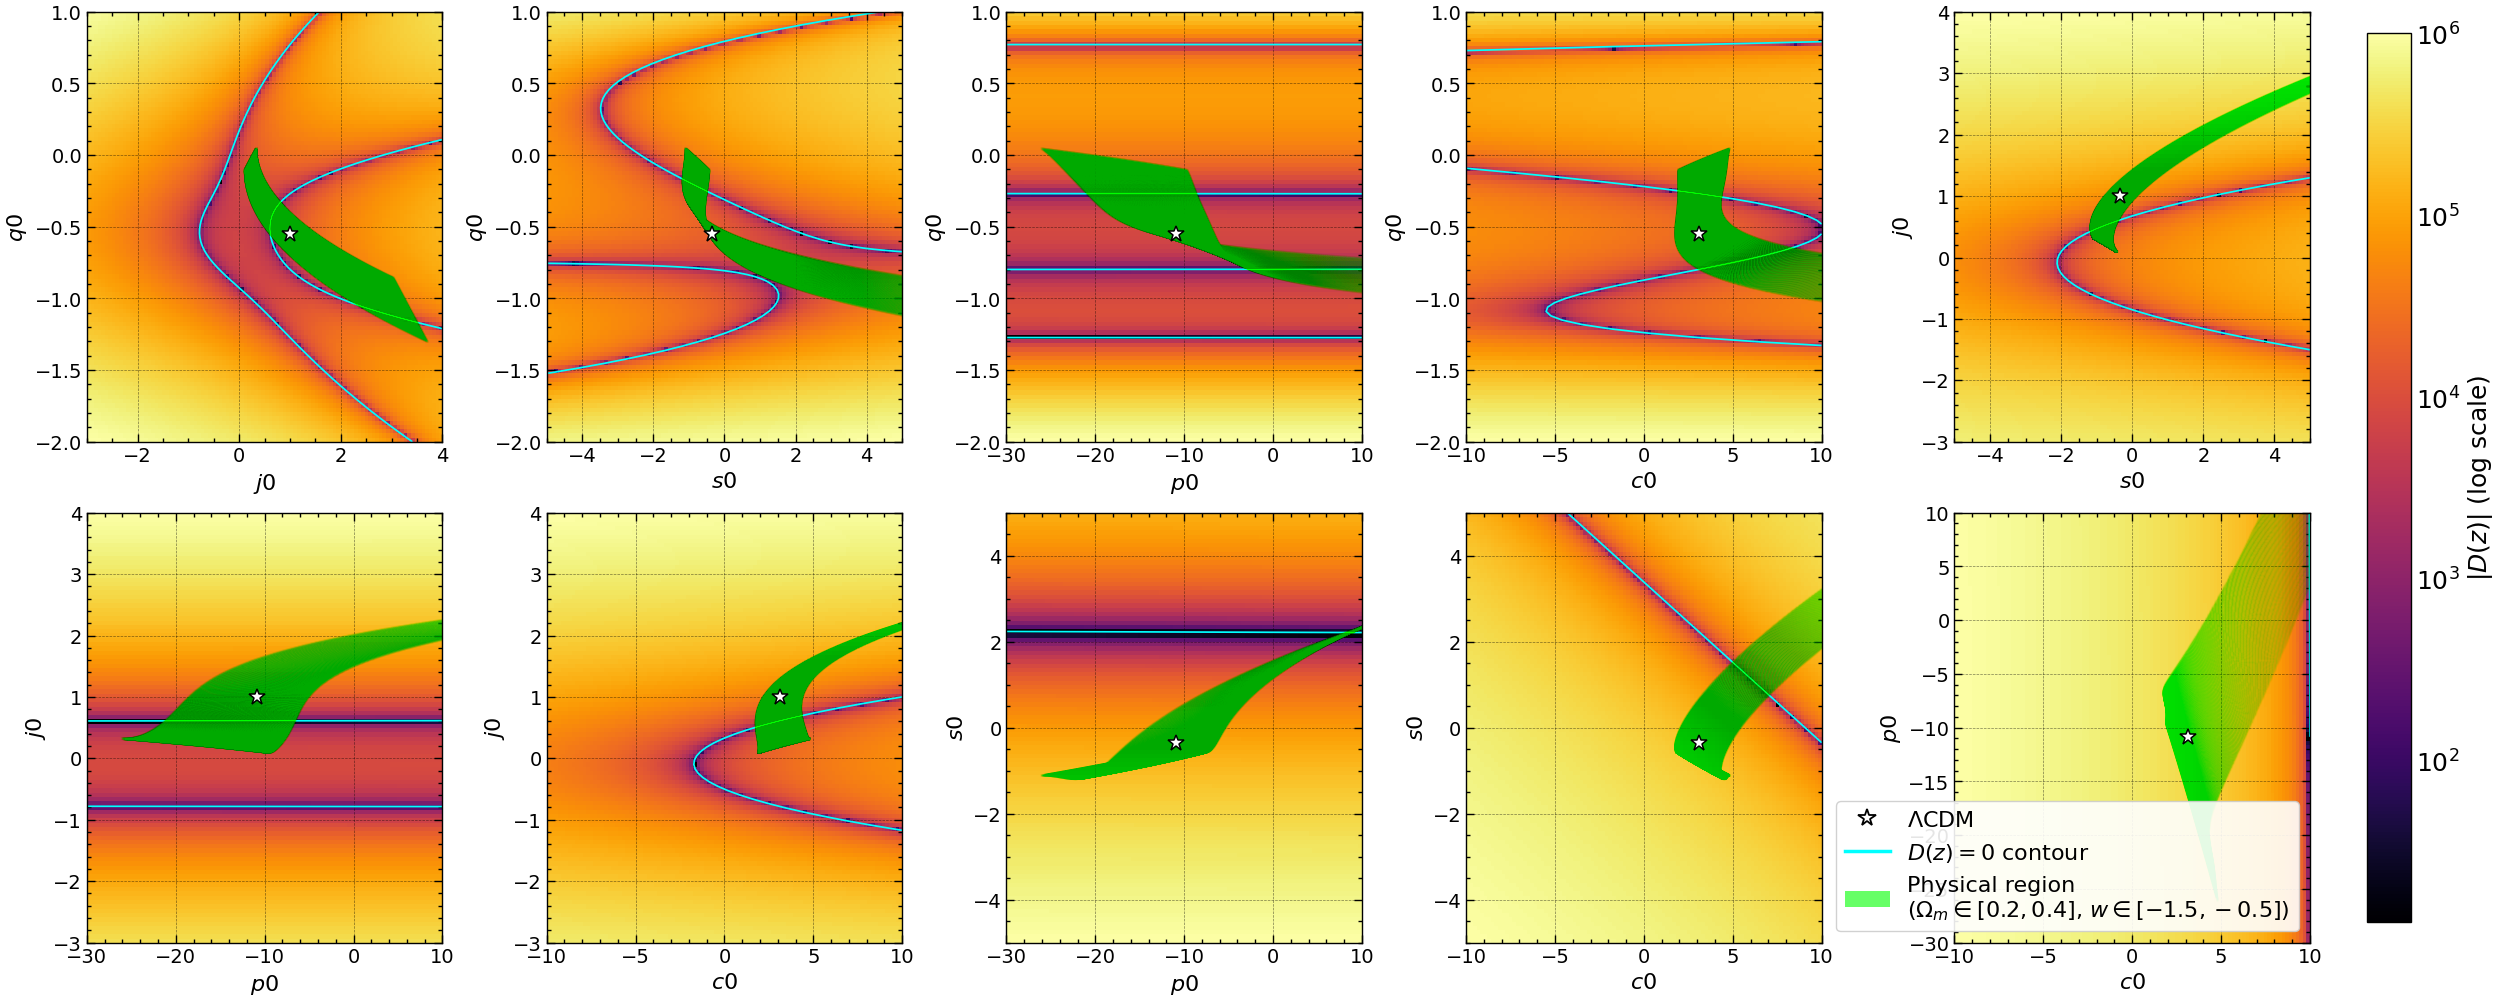

/tmp/ipykernel_28491/3276091039.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z[i, j] =denom


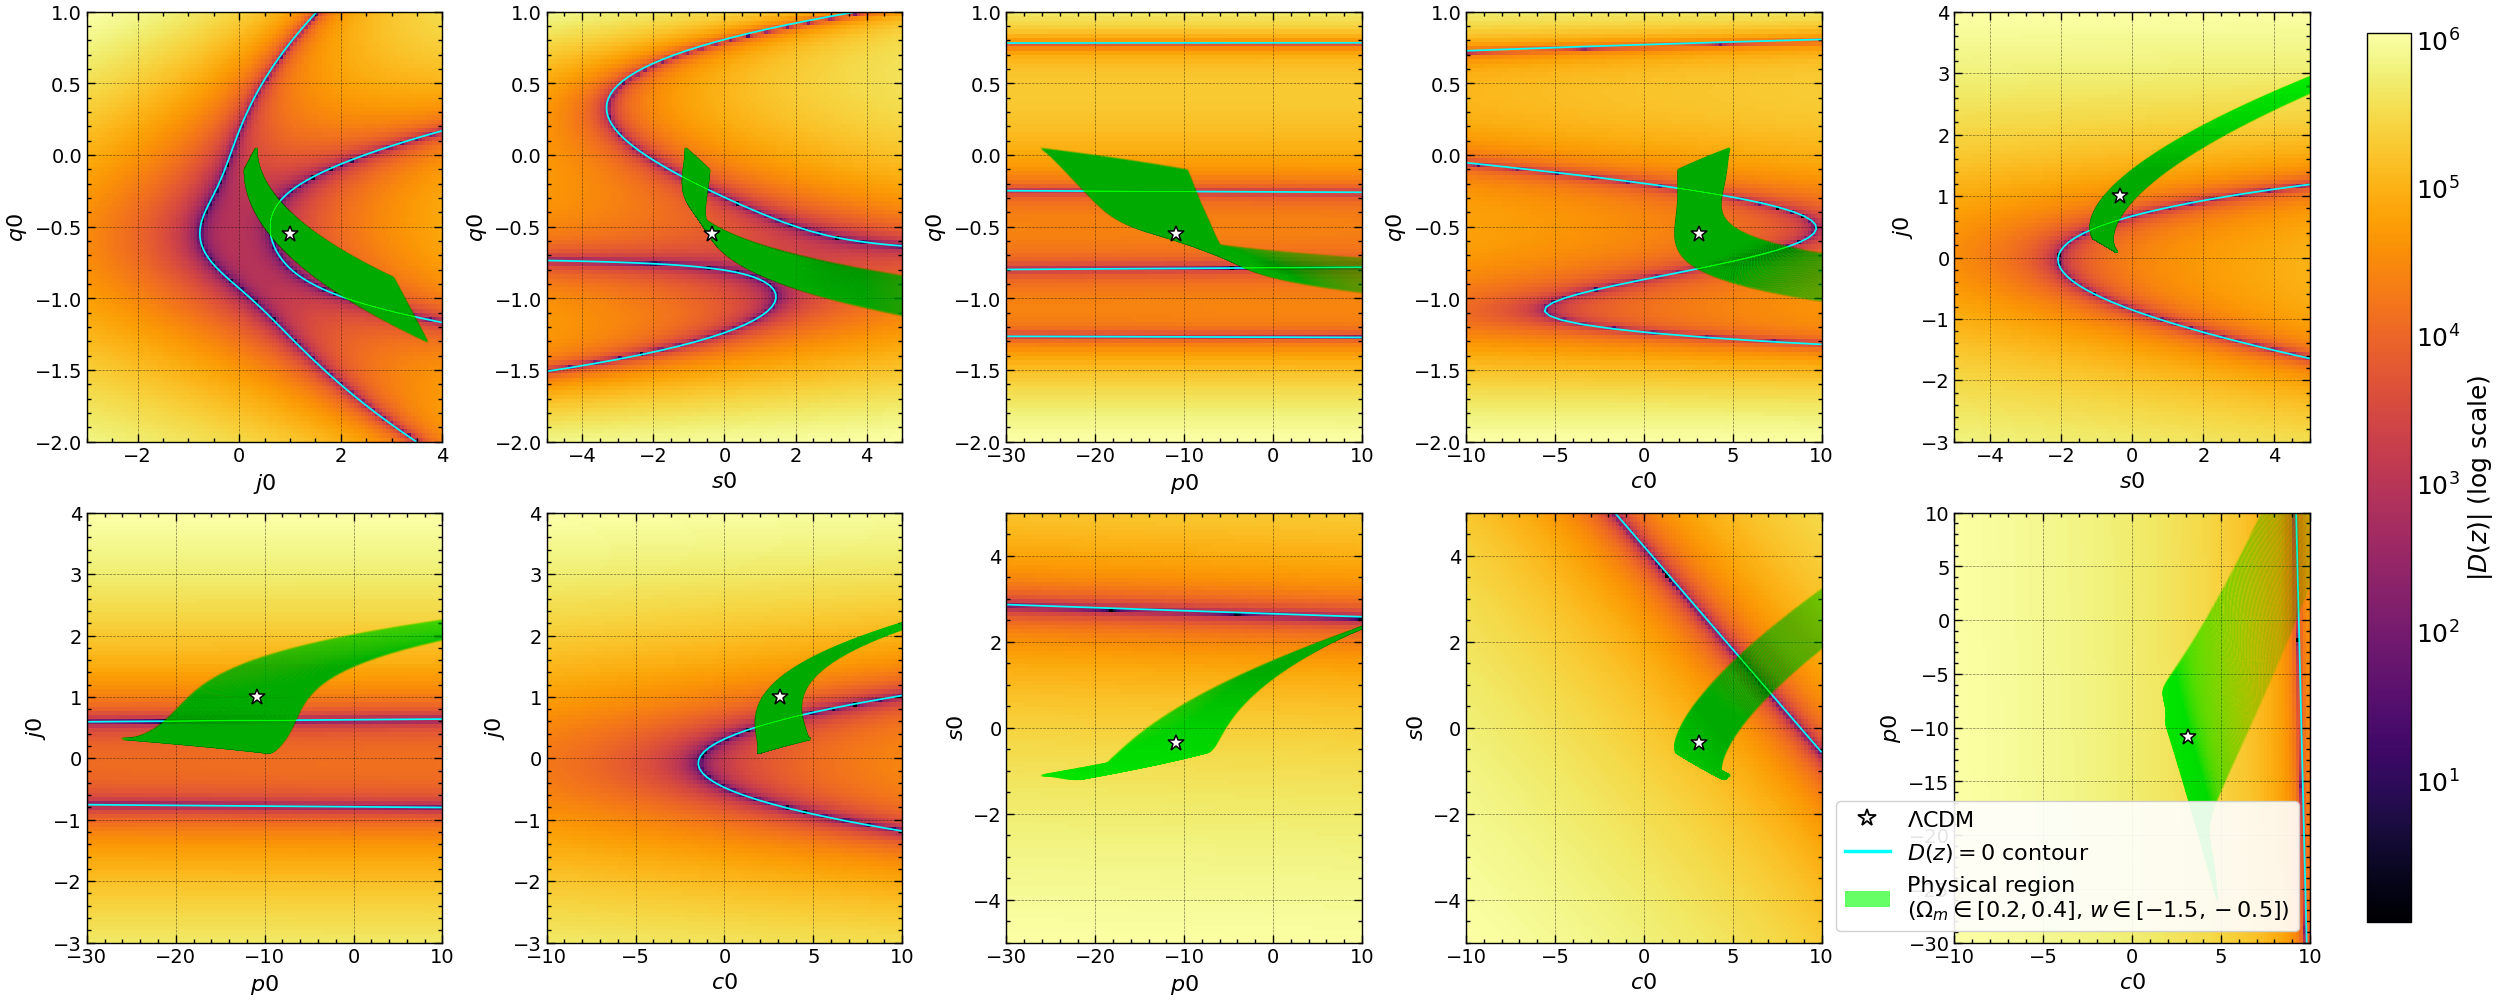

/tmp/ipykernel_28491/3276091039.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z[i, j] =denom


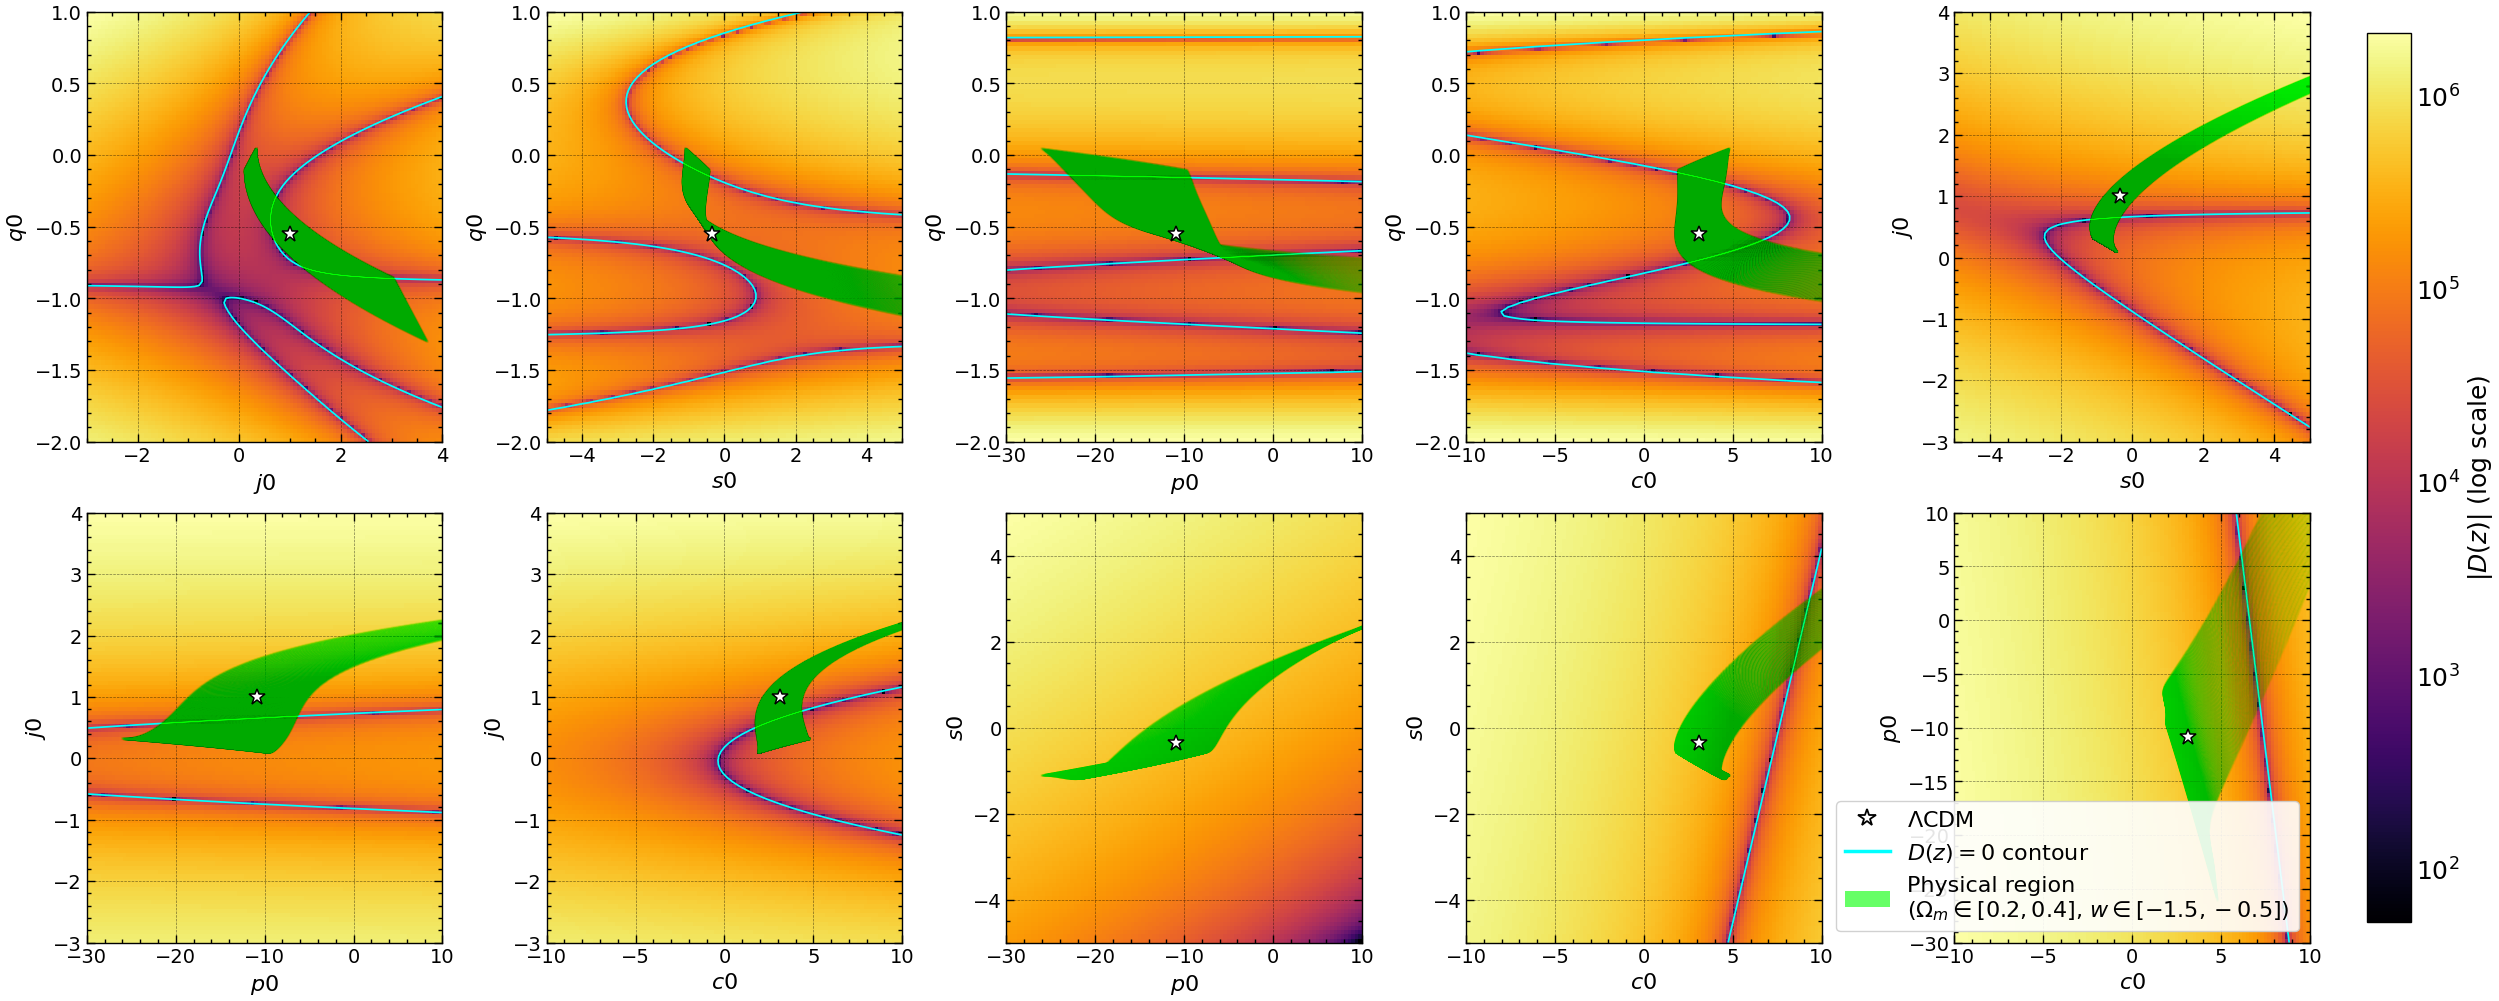

In [ ]:


# Create directory structure
# os.makedirs("Denominator plots/pade_51", exist_ok=True)

# for z_val in np.linspace(0.01, 5, 10):
#     fig, axes = plt.subplots(5, 3, figsize=(20, 25), constrained_layout=True)

#     for ax, (p1, r1, p2, r2) in zip(axes.flatten(), pairs):
#         Z = stability_map(r1, r2, base, p1, p2, z=np.array([z_val]),func = pade_51_denominator)
#         norm = TwoSlopeNorm(vmin=min(Z.min(),-1e-5), vcenter=0.0, vmax=max(Z.max(), 1e-5))
#         img = ax.imshow(Z, origin="lower", aspect="auto", norm=norm, cmap="seismic",
#                         extent=[r2.min(), r2.max(), r1.min(), r1.max()])
#         ax.contour(r2, r1, Z, levels=[0], colors='k', linewidths=2)
#         ax.plot(base[p2], base[p1], '*', color='magenta', markersize=8, label=r'$\Lambda$ CDM value')
#         ax.plot(base_range_1[p2],base_range_1[p1],color='lime',label = 'Variation around $\Omega_m$: 0.0-0.6')
#         ax.plot(base_range_2[p2],base_range_2[p1],color='orange',label = 'Variation around $\Omega_m$: 0.2-0.4')
#         ax.set_xlabel(p2)
#         ax.set_ylabel(p1)
#         ax.set_title(f"{p1} vs {p2} for z={z_val:.2f}")
#         ax.legend()
#     fig.colorbar(img, ax=axes, orientation='vertical', fraction=0.02, pad=0.02, label="D(z) (white = 0 line)")
#     plt.suptitle(f"Stability heatmaps: Denominator for Pade 5,1 D(z) at z={z_val:.2f}")
    
#     # Save the plot
#     plt.savefig(f"Denominator plots/pade_51/pade_51_z_{z_val:.2f}.png", dpi=150, bbox_inches='tight')
#     #plt.show()
#     plt.close()
#     #plt.close()



for z_val in [0.01, 0.1, 1]:
    fig, axes = plt.subplots(2, 5, figsize=(25, 10), constrained_layout=True)

    for ax, (p1, r1, p2, r2) in zip(axes.flatten(), pairs):
        Z = stability_map(r1, r2, base, p1, p2, z=np.array([z_val]), func=pade_51_denominator)
        
        # Use LogNorm for logarithmic color scaling
        Z_abs = np.abs(Z) + 1e-10
        norm = LogNorm(vmin=Z_abs.min(), vmax=Z_abs.max())
        
        img = ax.imshow(Z_abs, origin="lower", aspect="auto", norm=norm, cmap="inferno",
                        extent=[r2.min(), r2.max(), r1.min(), r1.max()])
        
        # Zero contour with higher contrast
        ax.contour(r2, r1, Z, levels=[0], colors='cyan', linewidths=1.25, linestyles='-')
        
        # Physical region
        x = CosmographicTransforms.to_cosmographic(70, om_range_grid, 0.0, w_range_grid)[var_dict_inv[p1]].flatten()
        y = CosmographicTransforms.to_cosmographic(70, om_range_grid, 0.0, w_range_grid)[var_dict_inv[p2]].flatten()
        ax.plot(y, x, '.', color='lime', alpha=0.01, markersize=1.5, rasterized=True)

        # Lambda CDM marker
        ax.plot(base[p2], base[p1], marker='*', color='white', markersize=12, 
                markeredgecolor='black', markeredgewidth=1.1, zorder=10)
        
        # Labels with larger font
        ax.set_xlabel(f'${p2}$', fontsize=16)
        ax.set_ylabel(f'${p1}$', fontsize=16)
        ax.tick_params(labelsize=14)
        ax.set_xlim(r2.min(), r2.max())
        ax.set_ylim(r1.min(), r1.max())
    
    # Custom legend
    legend_elements = [
        Line2D([0], [0], marker='*', color='w', markerfacecolor='white', 
               markeredgecolor='black', markeredgewidth=1.3, markersize=13, 
               label=r'$\Lambda$CDM', linestyle='None'),
        Line2D([0], [0], color='cyan', linewidth=2.5, label=r'$D(z)=0$ contour'),
        Patch(facecolor='lime', alpha=0.6, 
              label='Physical region\n'  
              r'($\Omega_m \in [0.2, 0.4]$, $w \in [-1.5, -0.5]$)')
    ]
    axes.flatten()[-1].legend(handles=legend_elements, loc='lower right', fontsize=16, framealpha=0.9)

    # Colorbar
    cbar = fig.colorbar(img, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
    cbar.set_label(r'$|D(z)|$ (log scale)', fontsize=18)
    cbar.ax.tick_params(labelsize=18)
    
    # Title
    #fig.suptitle(f'Padé (3,2) Denominator Stability at $z={z_val}$', fontsize=16, y=0.995)
    
    # plt.savefig(f"Denominator plots/pade_32/pade_32_z_{z_val:.2f}_publication.png", 
    #             dpi=300, bbox_inches='tight')
    plt.savefig(f"Denominator plots/pade_51/pade_51_z_{z_val:.2f}_w_om.pdf", 
                bbox_inches='tight')
    plt.show()
    plt.close()


In [ ]:
pade_42_denominator

<function __main__.pade_42_denominator(z: numpy.ndarray, H0: float, q0: float, j0: float = 0, s0: float = 0, c0: float = 0, p0: float = 0, Ok: float = 0, order: int = 0) -> numpy.ndarray>

In [ ]:
pairs[0][1]

array([-2.        , -1.96969697, -1.93939394, -1.90909091, -1.87878788,
       -1.84848485, -1.81818182, -1.78787879, -1.75757576, -1.72727273,
       -1.6969697 , -1.66666667, -1.63636364, -1.60606061, -1.57575758,
       -1.54545455, -1.51515152, -1.48484848, -1.45454545, -1.42424242,
       -1.39393939, -1.36363636, -1.33333333, -1.3030303 , -1.27272727,
       -1.24242424, -1.21212121, -1.18181818, -1.15151515, -1.12121212,
       -1.09090909, -1.06060606, -1.03030303, -1.        , -0.96969697,
       -0.93939394, -0.90909091, -0.87878788, -0.84848485, -0.81818182,
       -0.78787879, -0.75757576, -0.72727273, -0.6969697 , -0.66666667,
       -0.63636364, -0.60606061, -0.57575758, -0.54545455, -0.51515152,
       -0.48484848, -0.45454545, -0.42424242, -0.39393939, -0.36363636,
       -0.33333333, -0.3030303 , -0.27272727, -0.24242424, -0.21212121,
       -0.18181818, -0.15151515, -0.12121212, -0.09090909, -0.06060606,
       -0.03030303,  0.        ,  0.03030303,  0.06060606,  0.09

/tmp/ipykernel_28491/1748955143.py:14: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.18)
/tmp/ipykernel_28491/3276091039.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z[i, j] =denom


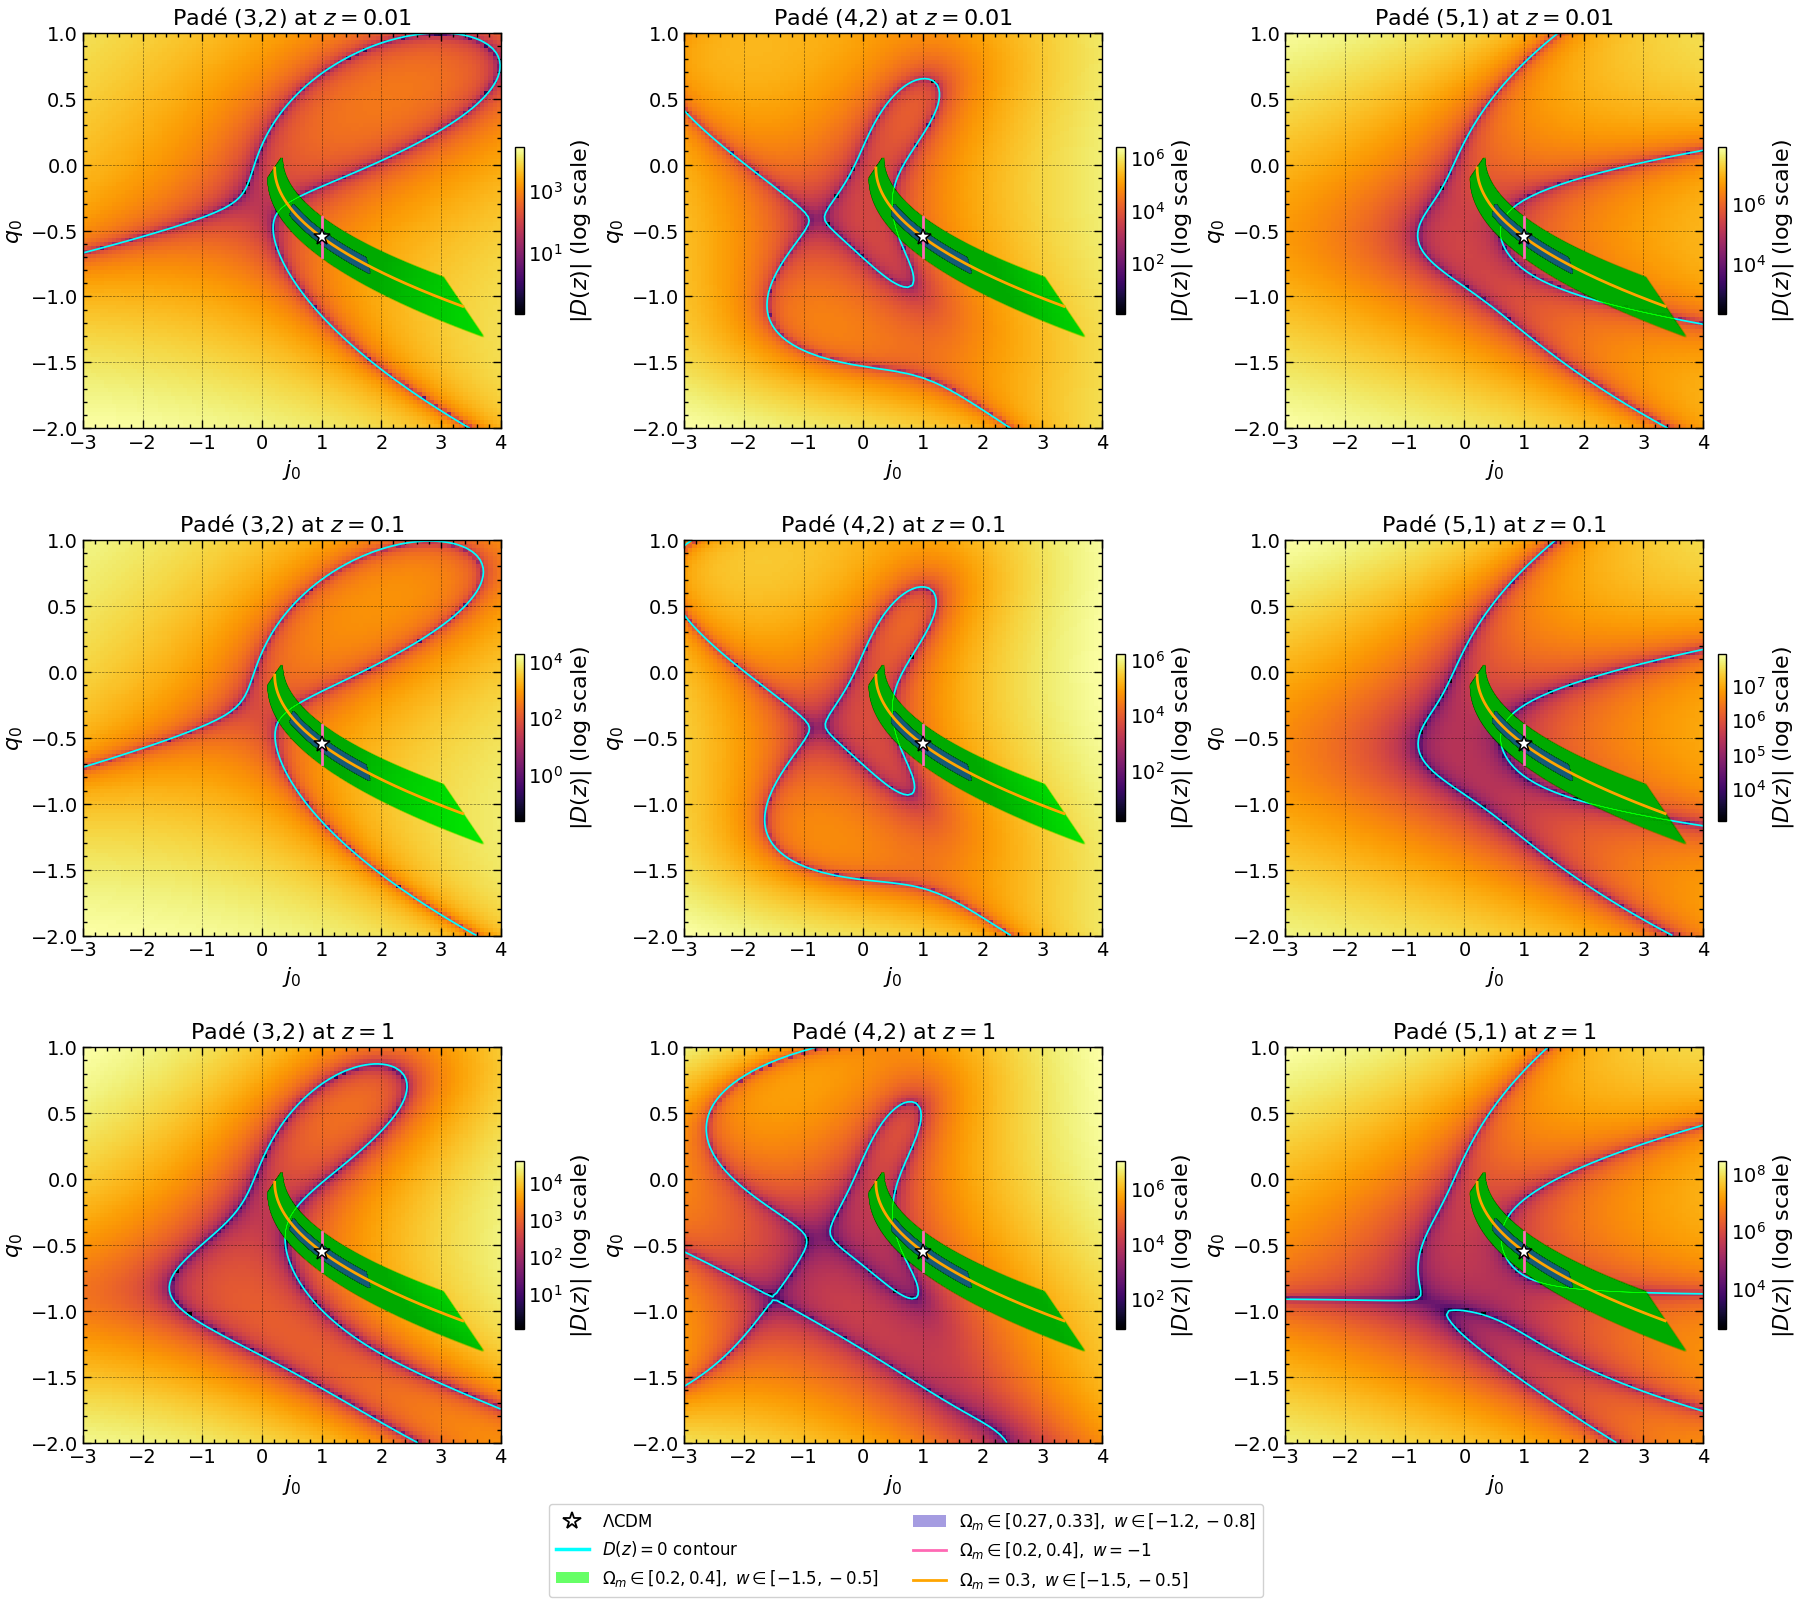

In [ ]:
om_range_broad = np.linspace(0.2, 0.4, 700)
w_range_broad = np.linspace(-1.5,-0.5,700)
om_range_grid_broad, w_range_grid_broad = np.meshgrid(om_range_broad, w_range_broad)

om_range_narrow = np.linspace(0.27, 0.33, 700)
w_range_narrow = np.linspace(-1.2,-0.8,700)
om_range_grid_narrow, w_range_grid_narrow = np.meshgrid(om_range_narrow, w_range_narrow)

labels = ['Padé (3,2)', 'Padé (4,2)', 'Padé (5,1)']
funcs = [pade_32_denominator, pade_42_denominator, pade_51_denominator]
z_vals = [0.01, 0.1, 1]

fig, axes = plt.subplots(3, 3, figsize=(18, 15), constrained_layout=True)
fig.subplots_adjust(bottom=0.18)
fig.set_constrained_layout_pads(hspace=0.06, wspace=0.02)
legend_elements = [
    Line2D([0], [0], marker='*', color='w', markerfacecolor='white',
           markeredgecolor='black', markeredgewidth=1.3, markersize=13,
           label=r'$\Lambda$CDM', linestyle='None'),
    Line2D([0], [0], color='cyan', linewidth=2.5, label=r'$D(z)=0$ contour'),
    Patch(facecolor='lime', alpha=0.6,
          label=r'$\Omega_m \in [0.2, 0.4],\ w \in [-1.5, -0.5]$'),
    Patch(facecolor='slateblue', alpha=0.6,
          label=r'$\Omega_m \in [0.27, 0.33],\ w \in [-1.2, -0.8]$'),
    Line2D([0], [0], color='hotpink', linewidth=2,
           label=r'$\Omega_m \in [0.2, 0.4],\ w=-1$'),
    Line2D([0], [0], color='orange', linewidth=2,
           label=r'$\Omega_m=0.3,\ w \in [-1.5, -0.5]$')
]
for row, z_val in enumerate(z_vals):
        for col, (func, label) in enumerate(zip(funcs, labels)):
                ax = axes[row, col]
                
                q0_extent = pairs[0][1]
                j0_extent = pairs[0][3]
                Z = stability_map(q0_extent, j0_extent, base, 'q0', 'j0', z=np.array([z_val]), func=func)
                Z_abs = np.abs(Z) + 1e-10
                norm = LogNorm(vmin=Z_abs.min(), vmax=Z_abs.max())

                img = ax.imshow(Z_abs, origin="lower", aspect="auto", norm=norm, cmap="inferno",
                                                extent=[j0_extent.min(), j0_extent.max(), q0_extent.min(), q0_extent.max()])

                ax.contour(j0_extent, q0_extent, Z, levels=[0], colors='cyan', linewidths=1.25, linestyles='-')
                
                # Broad physical region
                x_broad = CosmographicTransforms.to_cosmographic(70, om_range_grid_broad, 0.0, w_range_grid_broad)[var_dict_inv['q0']].flatten()
                y_broad = CosmographicTransforms.to_cosmographic(70, om_range_grid_broad, 0.0, w_range_grid_broad)[var_dict_inv['j0']].flatten()
                ax.plot(y_broad, x_broad, '.', color='lime', alpha=0.01, markersize=1.5, rasterized=True)
                
                # Narrow physical region
                x_broad_om_only = CosmographicTransforms.to_cosmographic(70, om_range_broad, 0.0, -1)[var_dict_inv['q0']].flatten()
                y_broad_om_only = CosmographicTransforms.to_cosmographic(70, om_range_broad, 0.0, -1)[var_dict_inv['j0']].flatten()
                x_broad_w_only = CosmographicTransforms.to_cosmographic(70, 0.3, 0.0, w_range_grid_broad)[var_dict_inv['q0']].flatten()
                y_broad_w_only = CosmographicTransforms.to_cosmographic(70, 0.3, 0.0, w_range_grid_broad)[var_dict_inv['j0']].flatten()
                x_narrow = CosmographicTransforms.to_cosmographic(70, om_range_grid_narrow, 0.0, w_range_grid_narrow)[var_dict_inv['q0']].flatten()
                y_narrow = CosmographicTransforms.to_cosmographic(70, om_range_grid_narrow, 0.0, w_range_grid_narrow)[var_dict_inv['j0']].flatten()
                ax.plot(y_narrow, x_narrow, '.', color='slateblue', alpha=0.01, markersize=1.5, rasterized=True)
                ax.plot(y_broad_om_only, x_broad_om_only, color='hotpink', alpha=1, rasterized=True)
                ax.plot(y_broad_w_only, x_broad_w_only, color='orange', alpha=1, rasterized=True)
                # Lambda CDM marker
                ax.plot(base['j0'], base['q0'], marker='*', color='white', markersize=12, 
                                markeredgecolor='black', markeredgewidth=1.1, zorder=10)

                ax.set_xlim(j0_extent.min(), j0_extent.max())
                ax.set_ylim(q0_extent.min(), q0_extent.max())
                ax.set_xlabel('$j_0$', fontsize=16)
                ax.set_ylabel('$q_0$', fontsize=16)
                ax.tick_params(labelsize=14)
                ax.set_title(f'{label} at $z={z_val}$', fontsize=16)
                # Custom legend (placed once, outside the loop, in the bottom-right subplot)


                # Colorbar (one per column)
                # if row == 2:
                cbar = fig.colorbar(img, ax=ax, orientation='vertical', 
                                                        fraction=0.02, pad=0.02)
                cbar.set_label(r'$|D(z)|$ (log scale)', fontsize=16)
                cbar.ax.tick_params(labelsize=14)
#plt.tight_layout()

fig.legend(
    handles=legend_elements,
    loc='lower left',
    bbox_to_anchor=(0.3, -0.07),
    fontsize=12,
    framealpha=0.9,ncol =2 
)

plt.savefig('Denominator q0_j0_all_pades_w_om_physical_regions.pdf', bbox_inches='tight', dpi=300)
plt.show()



/tmp/ipykernel_28491/3882554940.py:15: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.18)
/tmp/ipykernel_28491/3882554940.py:77: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.18)  # adjust this live


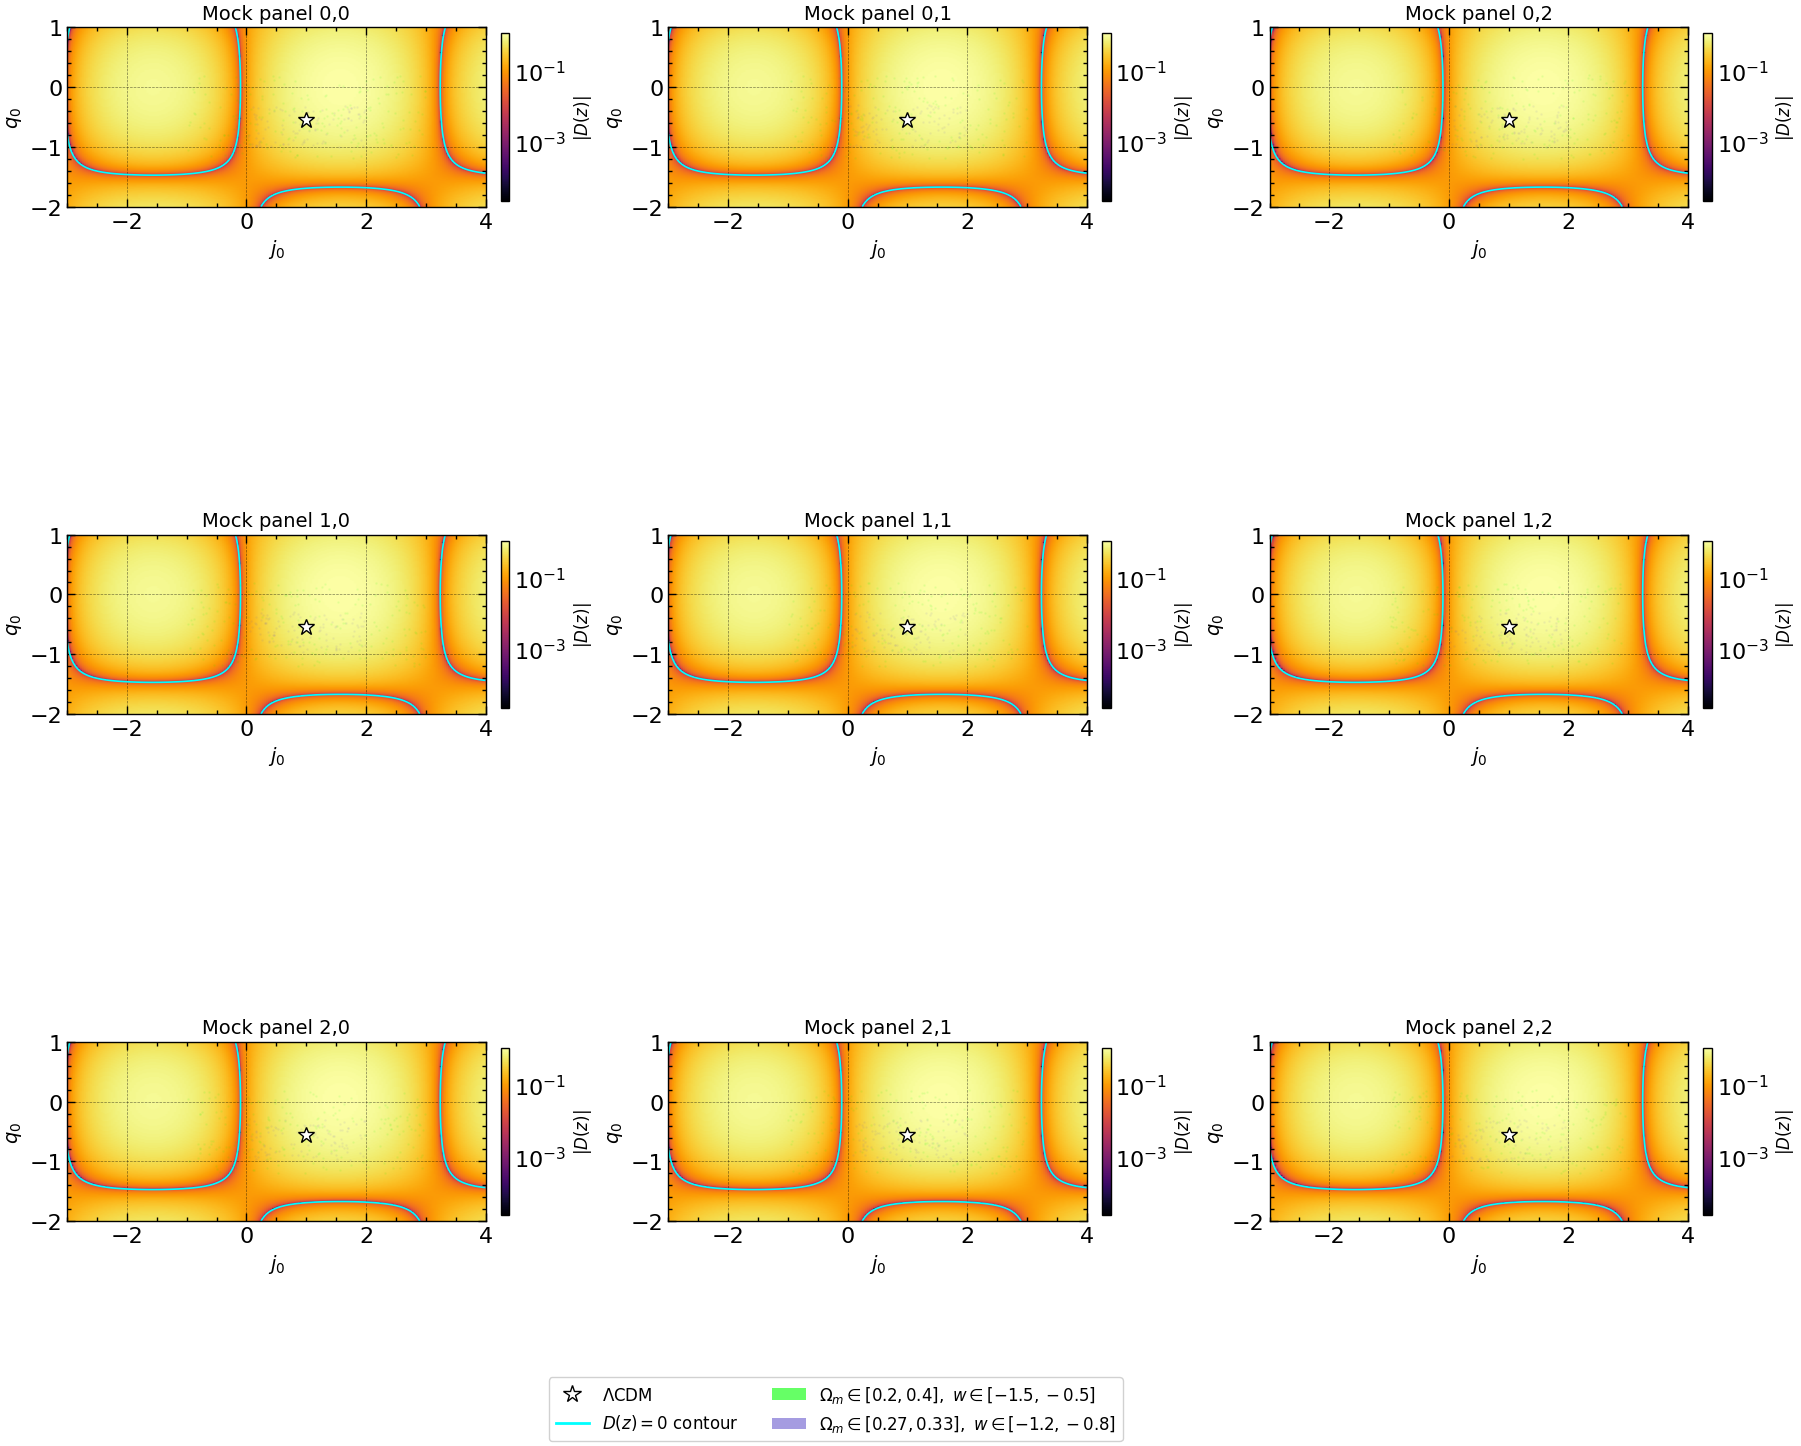

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.colors import LogNorm

# Fake data grid (cheap)
x = np.linspace(-3, 4, 200)
y = np.linspace(-2, 1, 200)
X, Y = np.meshgrid(x, y)
Z = np.sin(X) * np.cos(Y) + 0.1  # harmless nonsense

fig, axes = plt.subplots(3, 3, figsize=(18, 15), constrained_layout=True)
fig.set_constrained_layout_pads(hspace=0.06, wspace=0.02)
fig.subplots_adjust(bottom=0.18)

for i in range(3):
    for j in range(3):
        ax = axes[i, j]

        img = ax.imshow(
            np.abs(Z),
            origin="lower",
            extent=[x.min(), x.max(), y.min(), y.max()],
            cmap="inferno",
            norm=LogNorm()
        )

        # Fake contour
        ax.contour(X, Y, Z, levels=[0], colors='cyan', linewidths=1.2)

        # Fake scatter regions
        ax.plot(
            np.random.uniform(-1, 3, 200),
            np.random.uniform(-1.2, 0.2, 200),
            '.', color='lime', alpha=0.05, markersize=2
        )

        ax.plot(
            np.random.uniform(0, 2, 100),
            np.random.uniform(-1.0, -0.3, 100),
            '.', color='slateblue', alpha=0.05, markersize=2
        )

        # Fake ΛCDM marker
        ax.plot(1.0, -0.55, marker='*', color='white',
                markeredgecolor='black', markersize=12, zorder=10)

        ax.set_xlabel(r'$j_0$', fontsize=14)
        ax.set_ylabel(r'$q_0$', fontsize=14)
        ax.set_title(f'Mock panel {i},{j}', fontsize=14)

        cbar = fig.colorbar(img, ax=ax, fraction=0.02, pad=0.02)
        cbar.set_label(r'$|D(z)|$', fontsize=12)

# Legend elements (same as real code)
legend_elements = [
    Line2D([0], [0], marker='*', linestyle='None',
           markerfacecolor='white', markeredgecolor='black',
           markersize=13, label=r'$\Lambda$CDM'),
    Line2D([0], [0], color='cyan', linewidth=2,
           label=r'$D(z)=0$ contour'),
    Patch(facecolor='lime', alpha=0.6,
          label=r'$\Omega_m \in [0.2, 0.4],\ w \in [-1.5, -0.5]$'),
    Patch(facecolor='slateblue', alpha=0.6,
          label=r'$\Omega_m \in [0.27, 0.33],\ w \in [-1.2, -0.8]$'),
]

# 🔧 THIS IS WHAT YOU TUNE
fig.legend(
    handles=legend_elements,
    loc='lower left',
    bbox_to_anchor=(0.3, -0.05),
    fontsize=12,
    framealpha=0.9,ncol =2 
)
fig.subplots_adjust(bottom=0.18)  # adjust this live

plt.show()


In [ ]:
from itertools import combinations

E_ranges = {
    "E1": np.linspace(-1, 5, 80),
    "E2": np.linspace(-1, 5, 80),
    "E3": np.linspace(-5, 5, 80),
    "E4": np.linspace(-6, 5, 80),
    "E5": np.linspace(-5, 10, 80),
}
# Base values for E parameters
E_base = {
    "E1": 0.4500000000000002,
    "E2": 0.6975000000000002,
    "E3": -0.0416250000000012,
    "E4": -1.384593749999988,
    "E5": 3.405670312499811,
}

E_pairs = [
    (p1, E_ranges[p1], p2, E_ranges[p2])
    for p1, p2 in combinations(E_ranges.keys(), 2)
]





In [ ]:
def eis_stability_map(p1_vals, p2_vals, fixed, p1_name, p2_name, order=6,z = 0.1):
    Z = np.zeros((len(p1_vals), len(p2_vals)))
    for i, p1 in enumerate(p1_vals):
        for j, p2 in enumerate(p2_vals):
            params = fixed.copy()
            params[p1_name] = p1
            params[p2_name] = p2
            denom = eis_denominator(z, **params, order=order)
            Z[i, j] = denom
    return Z

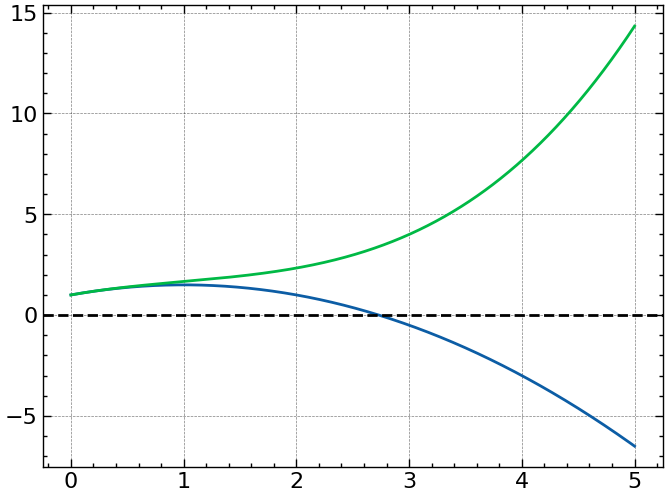

In [ ]:
plt.plot(z,eis_denominator(z, E1 = 1, E2=-1, E3=0, E4=0, E5=0, order=3))
plt.plot(z,eis_denominator(z, E1 = 1, E2=-1, E3=1, E4=0, E5=0, order=4))

plt.axhline(0, color='black', linestyle='--')

In [ ]:
# Create directory structure for EIS stability maps
os.makedirs("Denominator plots/EIS", exist_ok=True)

orders = [3, 4, 5, 6]

for z_val in np.linspace(0.01, 5, 10):
    for order in orders:
        os.makedirs(f"Denominator plots/EIS/O({order})", exist_ok=True)

        columns = min(order - 1, 3)
        rows = (math.comb(order - 1, 2) + columns - 1) // columns
        
        fig, axes = plt.subplots(rows, columns, figsize=(6 * columns, 5 * rows), constrained_layout=True)
        
        params = list(E_base.keys())[:order - 1]
        E_pairs_order = [(p1, E_ranges[p1], p2, E_ranges[p2]) for p1, p2 in combinations(params, 2)]
        
        for ax, (p1, r1, p2, r2) in zip(axes.flat, E_pairs_order):
            Z = stability_map(r1, r2, E_base, p1, p2, z=np.array([z_val]), func=lambda z, **kwargs: eis_denominator(z, **kwargs, order=order))
            norm = TwoSlopeNorm(vmin=min(Z.min(), -1e-5), vcenter=0.0, vmax=max(Z.max(), 1e-5))
            img = ax.imshow(Z, origin="lower", aspect="auto", norm=norm, cmap="seismic",
                            extent=[r2.min(), r2.max(), r1.min(), r1.max()])
            ax.contour(r2, r1, Z, levels=[0], colors='k', linewidths=2)
            ax.plot(E_base[p2], E_base[p1], '*', color='magenta', markersize=8, label=r'$\Lambda$ CDM value')
            ax.set_xlabel(p2)
            ax.set_ylabel(p1)
            ax.set_title(f"{p1} vs {p2} for z={z_val:.2f}")
            ax.legend()
        
        fig.colorbar(img, ax=axes, orientation='vertical', fraction=0.02, pad=0.02, label="D(z) (white = 0 line)")
        plt.suptitle(f"Stability heatmaps: Denominator for EIS D(z) Order {order} at z={z_val:.2f}")
        
        # Save the plot
        plt.savefig(f"Denominator plots/EIS/O({order})/EIS_order_{order}_z_{z_val:.2f}.png", dpi=150, bbox_inches='tight')
        plt.close()

/tmp/ipykernel_28491/3276091039.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z[i, j] =denom


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
for ax, (p1, r1, p2, r2) in zip(axes.flat, pairs):
    Z = stability_map(r1, r2, base, p1, p2)
    norm = TwoSlopeNorm(vmin=Z.min(), vcenter=0.0, vmax=Z.max())
    img = ax.imshow(Z, origin="lower", aspect="auto", norm=norm, cmap="seismic",
                    extent=[r2.min(), r2.max(), r1.min(), r1.max()])
    ax.contour(r2, r1, Z, levels=[0], colors='k', linewidths=2)
    ax.plot(base[p2], base[p1], '*', color='magenta', markersize=8, label=r'$\Lambda$ CDM value')
    ax.set_xlabel(p2)
    ax.set_ylabel(p1)
    ax.set_title(f"{p1} vs {p2}")
    ax.legend()
fig.colorbar(img, ax=axes, orientation='vertical', fraction=0.02, pad=0.02, label="min(D(z)) (white = 0 line)")
plt.suptitle("Stability heatmaps: min Denominator for Pade 3,2 D(z)")
plt.show()

In [ ]:
###Caution this is not a denomiatior debus but a full function debug

def z_series( z: np.ndarray, H0: float, q0: float, j0: float = 0,
    s0: float = 0, c0: float = 0, p0: float = 0, Ok: float = 0, order: int = 3) -> np.ndarray:
    # compute coefficients (a0..a5) same as original file; here we compute a subset for readability
    
    a0 = 1.0
    a1 = 1.0/2.0 - q0/2.0
    a2 = -1.0/6.0 - j0/6.0 + q0/6.0 + q0**2/2.0 + Ok/6.0
    a3 = (1.0/12.0 + 5*j0/24.0 - q0/12.0 + 5.0*j0*q0/12.0 - 
            5.0*q0**2/8.0 - 5.0*q0**3/8.0 + s0/24.0 - Ok/12.0 - Ok*q0/4.0)
    a4 = (-1.0/20.0 - 9*j0/40.0 + j0**2/12.0 - c0/120.0 + q0/20.0 - 
            11*j0*q0/12.0 + 27*q0**2/40.0 - 7*j0*q0**2/8.0 + 11*q0**3/8.0 + 
            7*q0**4/8.0 - 11*s0/120.0 - q0*s0/8.0 - Ok**2 - 
            5*Ok*(2*j0 - 9*q0**2 - 8*q0 - 1))
    a5 = (1.0/30.0 + 7*j0/30.0 - 19.0*j0**2/72.0 + 19.0*c0/720.0 + 
            p0/720.0 - q0/30.0 + 13*j0*q0/9.0 - 7*j0**2*q0/18.0 + 
            7*c0*q0/240.0 - 7*q0**2/10.0 + 133.0*j0*q0**2/48.0 - 
            13.0*q0**3/6.0 + 7.0*j0*q0**3/4.0 - 133.0*q0**4/48.0 - 
            21.0*q0**5/16.0 + 13.0*s0/90.0 - 7.0*j0*s0/144.0 + 
            19.0*q0*s0/48.0 + 7*q0**2*s0/24.0 - 
            15.*Ok*(-14*j0*q0 - 9*j0 + 28*q0**3 + 40*q0**2 + 17*q0 - s0 + 1) - 
            Ok**2*(15*q0 + 9))
    return (3e5 / H0) * (z + a1 * z**2 + a2 * z**3 + a3 * z**4 + a4 * z**5 + a5 * z**6)

def z_a5(q0,j0,s0,c0,p0,Ok):
    a5 = (1.0/30.0 + 7*j0/30.0 - 19.0*j0**2/72.0 + 19.0*c0/720.0 + 
            p0/720.0 - q0/30.0 + 13*j0*q0/9.0 - 7*j0**2*q0/18.0 + 
            7*c0*q0/240.0 - 7*q0**2/10.0 + 133.0*j0*q0**2/48.0 - 
            13.0*q0**3/6.0 + 7.0*j0*q0**3/4.0 - 133.0*q0**4/48.0 - 
            21.0*q0**5/16.0 + 13.0*s0/90.0 - 7.0*j0*s0/144.0 + 
            19.0*q0*s0/48.0 + 7*q0**2*s0/24.0 - 
            15.*Ok*(-14*j0*q0 - 9*j0 + 28*q0**3 + 40*q0**2 + 17*q0 - s0 + 1) - 
            Ok**2*(15*q0 + 9))

    return a5




In [ ]:
q0_range = np.linspace(-2, 1, 100)
j0_range = np.linspace(-3, 4, 100)
s0_range = np.linspace(-5, 5, 100)
c0_range = np.linspace(-10, 10, 100)
p0_range = np.linspace(-30, 10, 100)
Ok = 0

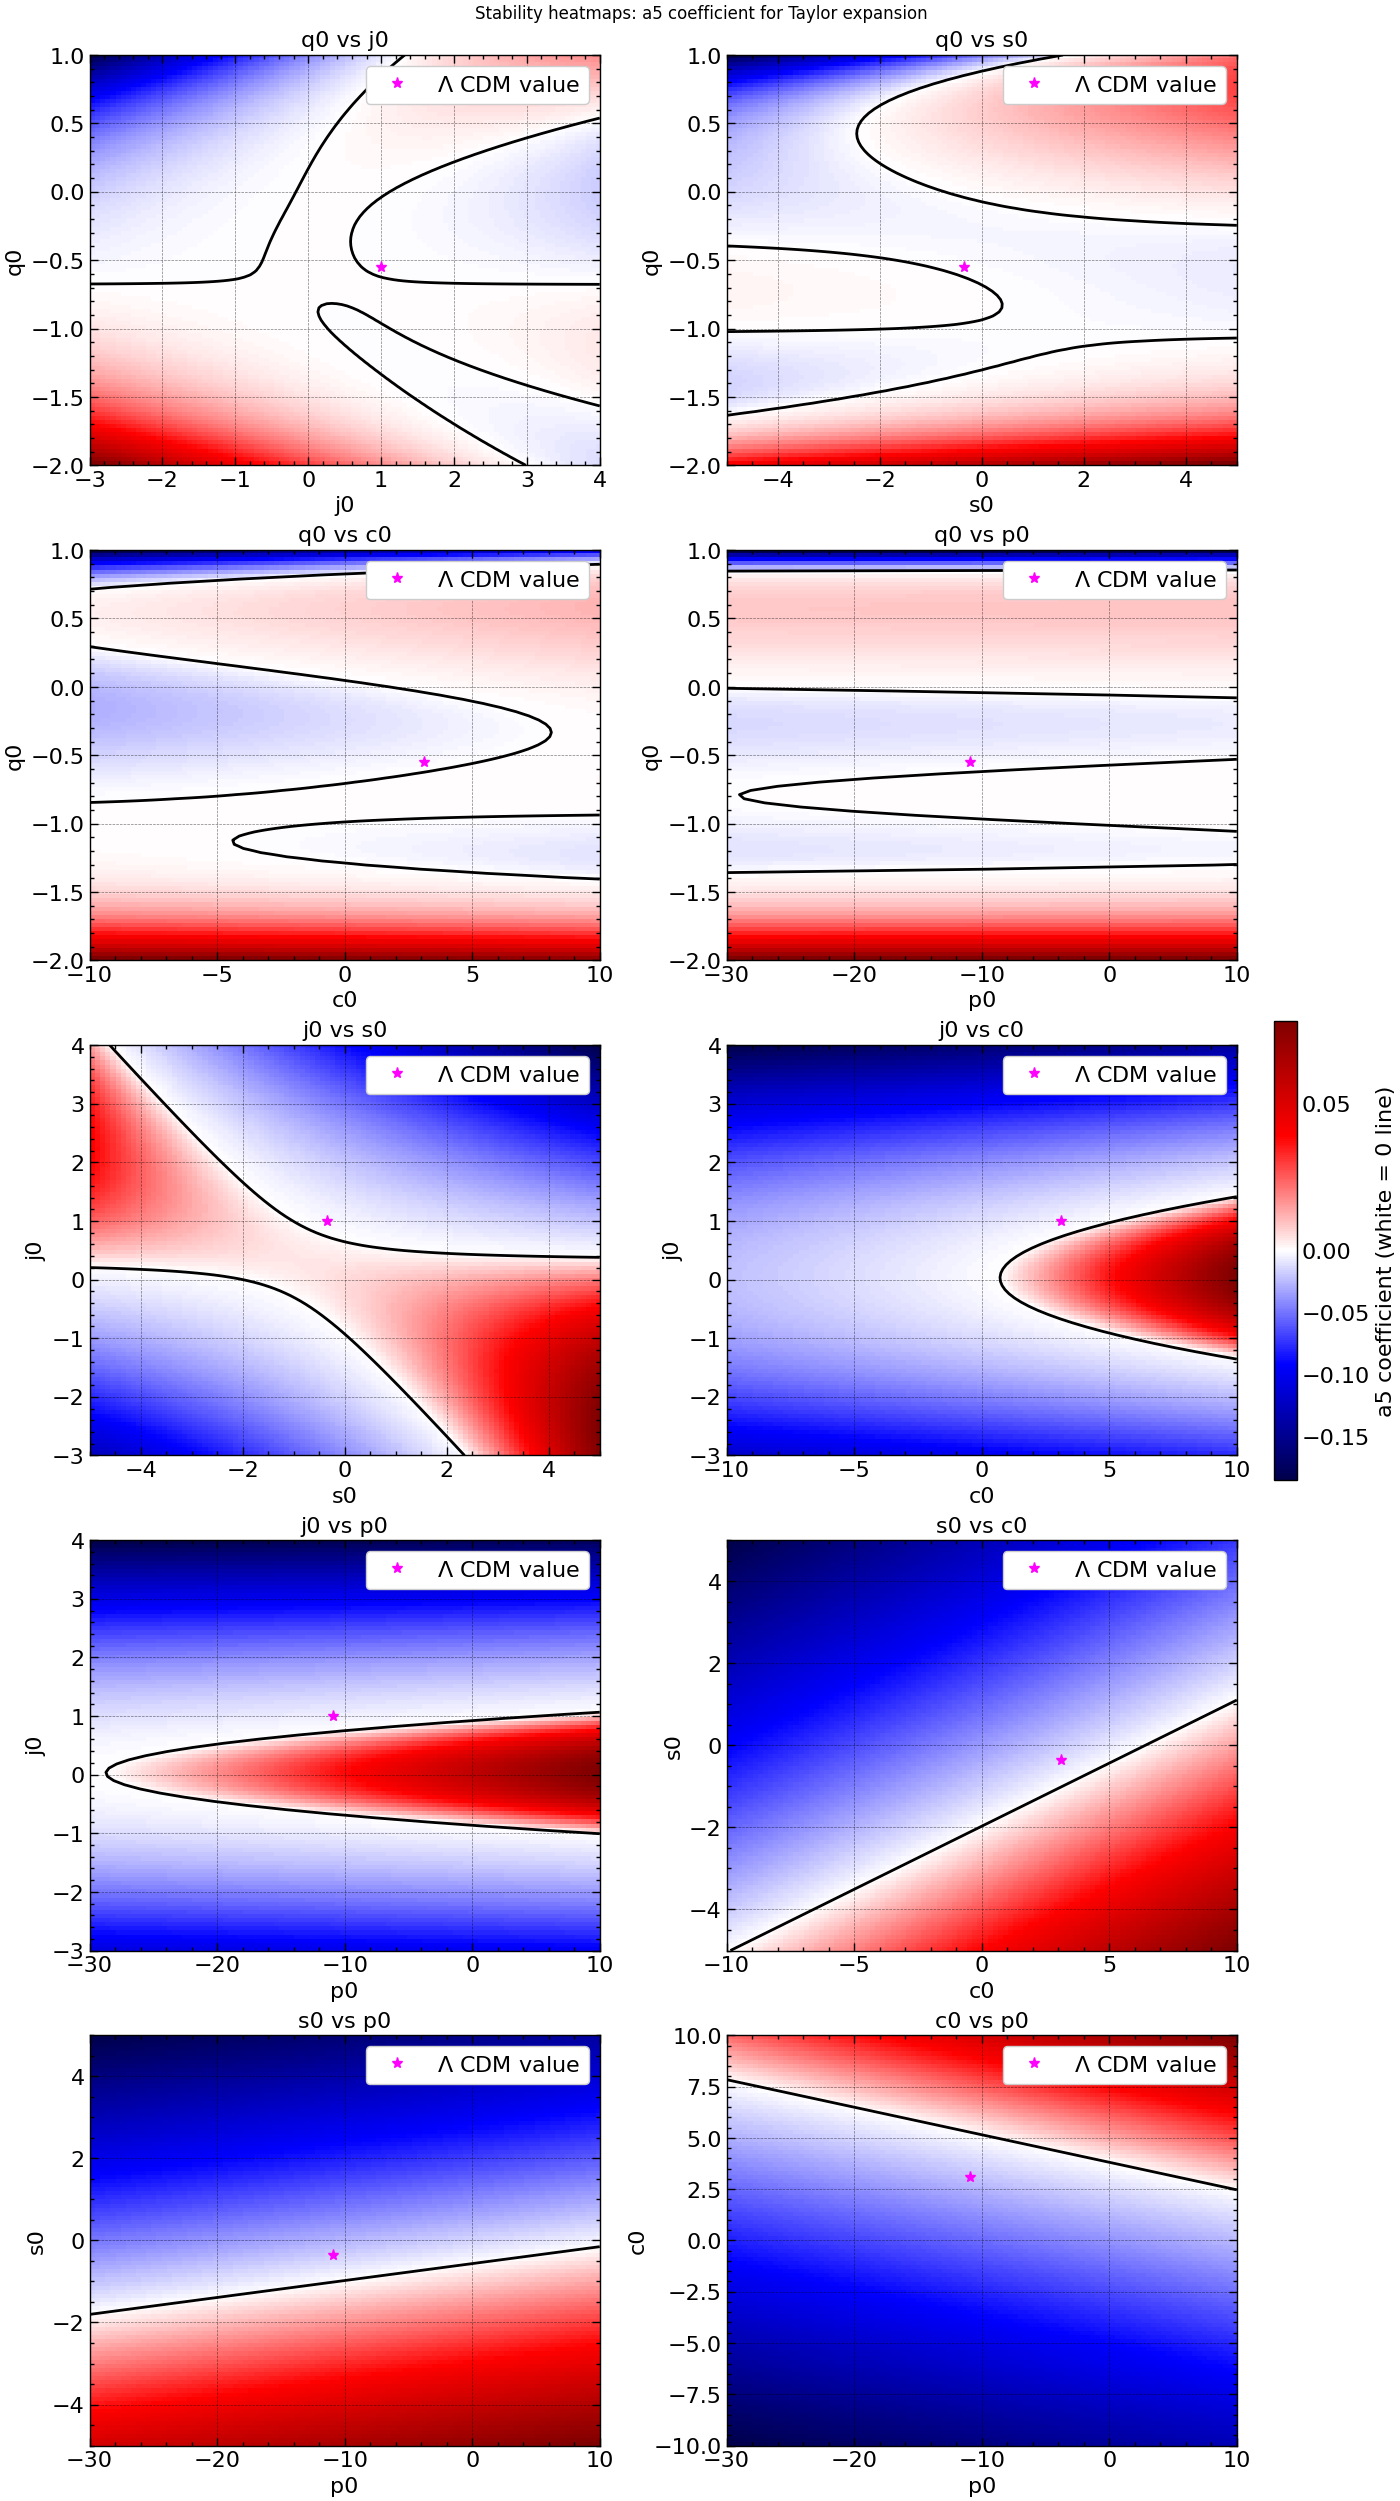

In [ ]:
# Create directory structure for a5 coefficient plots
os.makedirs("Denominator plots/a5_coefficient", exist_ok=True)

# Define parameter ranges for a5
a5_param_ranges = {
    "q0": q0_range,
    "j0": j0_range,
    "s0": s0_range,
    "c0": c0_range,
    "p0": p0_range,
}

# Base values for a5 (same as before but without H0)
a5_base = {
    "q0": -0.55,
    "j0": 1.0,
    "s0": -0.35,
    "c0": 3.11,
    "p0": -10.886749999999894,
}

# Generate all unique pairs for a5
a5_pairs = [
    (p1, a5_param_ranges[p1], p2, a5_param_ranges[p2])
    for p1, p2 in combinations(a5_param_ranges.keys(), 2)
]

# Create stability map for a5
def a5_stability_map(p1_vals, p2_vals, fixed, p1_name, p2_name):
    Z = np.zeros((len(p1_vals), len(p2_vals)))
    for i, p1 in enumerate(p1_vals):
        for j, p2 in enumerate(p2_vals):
            params = fixed.copy()
            params[p1_name] = p1
            params[p2_name] = p2
            Z[i, j] = z_a5(**params, Ok=Ok)
    return Z

# Plot all parameter pairs
fig, axes = plt.subplots(5, 2, figsize=(14, 25), constrained_layout=True)

for ax, (p1, r1, p2, r2) in zip(axes.flatten(), a5_pairs):
    Z = a5_stability_map(r1, r2, a5_base, p1, p2)
    norm = TwoSlopeNorm(vmin=min(Z.min(), -1e-5), vcenter=0.0, vmax=max(Z.max(), 1e-5))
    img = ax.imshow(Z, origin="lower", aspect="auto", norm=norm, cmap="seismic",
                    extent=[r2.min(), r2.max(), r1.min(), r1.max()])
    ax.contour(r2, r1, Z, levels=[0], colors='k', linewidths=2)
    ax.plot(a5_base[p2], a5_base[p1], '*', color='magenta', markersize=8, label=r'$\Lambda$ CDM value')
    ax.set_xlabel(p2)
    ax.set_ylabel(p1)
    ax.set_title(f"{p1} vs {p2}")
    ax.legend()

fig.colorbar(img, ax=axes, orientation='vertical', fraction=0.02, pad=0.02, label="a5 coefficient (white = 0 line)")
plt.suptitle("Stability heatmaps: a5 coefficient for Taylor expansion")

# Save the plot
plt.savefig("Denominator plots/a5_coefficient/a5_coefficient_all_pairs.png", dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [ ]:
# Create directory structure for z_series Taylor expansion plots
os.makedirs("Denominator plots/z_series_taylor", exist_ok=True)

# Define parameter ranges (already defined in previous cells)
taylor_param_ranges = {
    "q0": q0_range,
    "j0": j0_range,
    "s0": s0_range,
    "c0": c0_range,
    "p0": p0_range,
}

# Base values for Taylor expansion
taylor_base = {
    "H0": 70.0,
    "q0": -0.55,
    "j0": 1.0,
    "s0": -0.35,
    "c0": 3.11,
    "p0": -10.886749999999894,
}

# Generate all unique pairs for Taylor expansion
taylor_pairs = [
    (p1, taylor_param_ranges[p1], p2, taylor_param_ranges[p2])
    for p1, p2 in combinations(taylor_param_ranges.keys(), 2)
]

# Generate plots for different z values
for z_val in np.linspace(0.01, 5, 10):
    fig, axes = plt.subplots(5, 2, figsize=(14, 25), constrained_layout=True)

    for ax, (p1, r1, p2, r2) in zip(axes.flatten(), taylor_pairs):
        Z = stability_map(r1, r2, taylor_base, p1, p2, z=np.array([z_val]), 
                         func=lambda z, **kwargs: z_series(z, **kwargs, order=6))
        norm = TwoSlopeNorm(vmin=min(Z.min(), -1e-5), vcenter=0.0, vmax=max(Z.max(), 1e-5))
        img = ax.imshow(Z, origin="lower", aspect="auto", norm=norm, cmap="seismic",
                        extent=[r2.min(), r2.max(), r1.min(), r1.max()])
        ax.contour(r2, r1, Z, levels=[0], colors='k', linewidths=2)
        ax.plot(taylor_base[p2], taylor_base[p1], '*', color='magenta', markersize=8, 
               label=r'$\Lambda$ CDM value')
        ax.set_xlabel(p2)
        ax.set_ylabel(p1)
        ax.set_title(f"{p1} vs {p2} for z={z_val:.2f}")
        ax.legend()

    fig.colorbar(img, ax=axes, orientation='vertical', fraction=0.02, pad=0.02, 
                label="D_L(z) (white = 0 line)")
    plt.suptitle(f"Stability heatmaps: Taylor expansion (Order 6) D_L(z) at z={z_val:.2f}")
    
    # Save the plot
    plt.savefig(f"Denominator plots/z_series_taylor/z_series_order6_z_{z_val:.2f}.png", 
               dpi=150, bbox_inches='tight')
    plt.close()


/tmp/ipykernel_211325/3276091039.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z[i, j] =denom


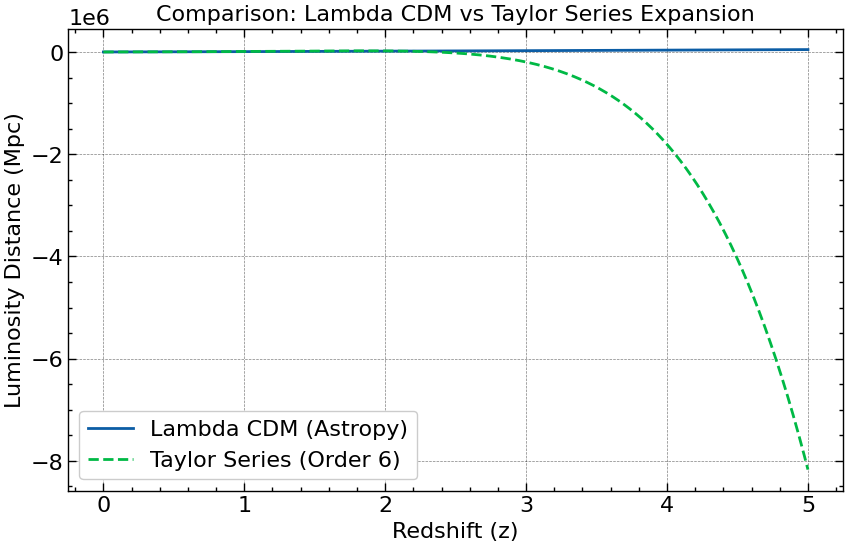

/tmp/ipykernel_211325/50044461.py:23: RuntimeWarning: invalid value encountered in divide
  fractional_diff = (d_L_taylor - d_L_lcdm) / d_L_lcdm * 100


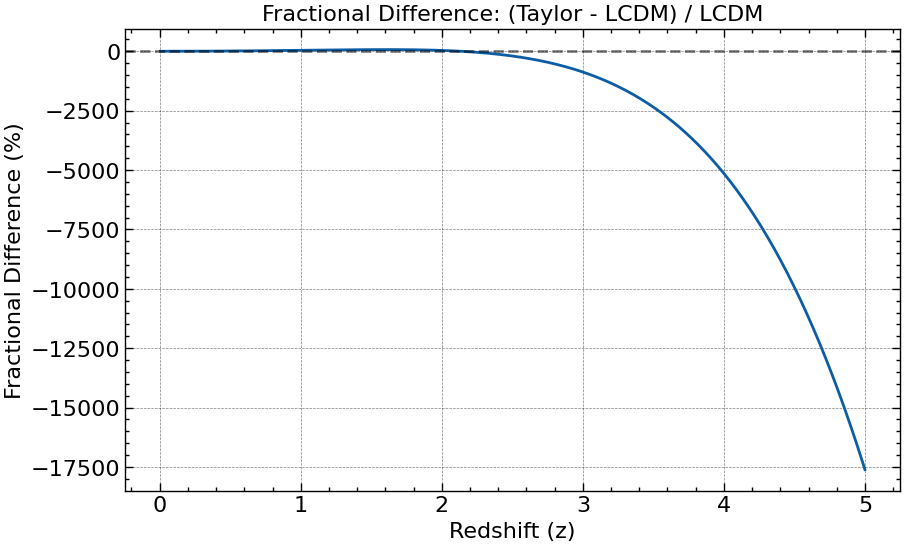

In [ ]:
# Plot comparison between Taylor series and Lambda CDM
cosmo_lcdm = FlatLambdaCDM(H0=70.0, Om0=0.3)

# Compute Lambda CDM luminosity distance
d_L_lcdm = cosmo_lcdm.luminosity_distance(z).value  # in Mpc

# Compute Taylor series luminosity distance
d_L_taylor = z_series(z, H0=70.0, q0=-0.55, j0=-2.0, s0=-0.35, c0=3.11, p0=-10.886749999999894, order=6)

# Plot both
plt.figure(figsize=(10, 6))
plt.plot(z, d_L_lcdm, label='Lambda CDM (Astropy)', linewidth=2)
plt.plot(z, d_L_taylor, label='Taylor Series (Order 6)', linestyle='--', linewidth=2)
plt.xlabel('Redshift (z)')
plt.ylabel('Luminosity Distance (Mpc)')
plt.title('Comparison: Lambda CDM vs Taylor Series Expansion')
plt.legend()
plt.grid(True)
plt.show()

# Plot fractional difference
plt.figure(figsize=(10, 6))
fractional_diff = (d_L_taylor - d_L_lcdm) / d_L_lcdm * 100
plt.plot(z, fractional_diff, linewidth=2)
plt.xlabel('Redshift (z)')
plt.ylabel('Fractional Difference (%)')
plt.title('Fractional Difference: (Taylor - LCDM) / LCDM')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.grid(True)
plt.show()